# YEAR 2 Nutrient Analysis

In [ ]:
Samples taken one year after experiment

In [2]:
library(lme4) #for linear mixed effects model
library(readr) #to read in data
library(emmeans) #for post hocs
library(esquisse) #interface for building plots
library(dplyr) #for data wrangling
library(nlme) #for linear mixed effects model
library(car) #for the Levene test
library(ggplot2) #for graphs
library(plotrix) #for standard error
library(performance) #model testing
library(lmtest) #another option than levene test for variance

In [3]:
setwd("/Users/sophiemontague/Desktop/MontagueORCC_repo/MontagueORCC")
getwd()

[1] "/Users/sophiemontague/Desktop/MontagueORCC_repo/MontagueORCC"

In [ ]:
# Below is NOT updated, need to swap over from phase 2 to year 2

## 0. Data Formatting

In [4]:
year2 <- read_csv("Year_2_Data/Nutrients/Nutrient_YEAR2_working.csv")
Phase1_info <- read_csv("Oyster_Weight_Data/growth_phase2.1_weightsSKM.csv")

New names:
• `` -> `...16`
Rows: 374 Columns: 16
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (11): Sample_Name_Nutrients, Phase_2_treat, Phase_2_rep, Phase_2_rep_R, ...
dbl  (5): Tag_num, Linear corr d15N, wt_percent_n, Linear corr d13C, wt_perc...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 1152 Columns: 37
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (20): Sample_Name, Date_MMDDYYYY_pre, Phase_1_treat, Phase_1_rep, Phase_...
dbl (17): Order_pre, Year, Tag_num, Submerged_weight_pre, Dry_weight_pre, Or...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [38]:
colnames(Phase1_info)

[1] "Sample_Name"               "Order_pre"                
 [3] "Date_MMDDYYYY_pre"         "Year"                     
 [5] "Phase_1_treat"             "Phase_1_rep"              
 [7] "Phase_2_treat"             "Phase_2_rep"              
 [9] "Tag_color"                 "Tag_num"                  
[11] "Submerged_weight_pre"      "Dry_weight_pre"           
[13] "Notes_pre"                 "Order_post"               
[15] "Date_MMDDYYYY_post"        "Submerged_weight_post"    
[17] "Dry_weight_post"           "double_single_dead"       
[19] "Notes_post"                "Actual_shell_pre_mg"      
[21] "Actual_shell_post_mg"      "Actual_shell_growth_mg"   
[23] "Actual_tissue_pre_mg"      "Actual_tissue_post_mg"    
[25] "Actual_tissue_growth_mg"   "Ratio_tissue_shell_mg"    
[27] "Phase_1_temp"              "Phase_1_DO"               
[29] "Phase_2.1_temp"            "Phase_2.1_DO"             
[31] "Phase1_Phase2_treat"       "Phase_1_rep_R"            
[33] "Phase_2_rep_R"             "Ratio_tissue_shell_pre_mg"
[35] "Phase1_Phase2_rep"         "Exclude_all"              
[37] "Exclude_pre_analysis"

In [6]:
#Add in treatment groups etc.
nutrient_df <- year2 %>%
  inner_join(
    Phase1_info %>%
      select(
        Phase_2_rep_R, Sample_Name, Phase_1_treat, Phase_1_rep, Phase_1_rep_R,
        Tag_color, Tag_num, Notes_pre, Notes_post,
        Actual_shell_pre_mg, Actual_shell_post_mg, Actual_shell_growth_mg,
        Actual_tissue_pre_mg, Actual_tissue_post_mg, Actual_tissue_growth_mg,
        Phase_1_temp, Phase_1_DO, Phase_2.1_temp, Phase_2.1_DO,
        Exclude_all), 
      by = c("Phase_2_rep_R", "Tag_color", "Tag_num"))

In [7]:
colnames(nutrient_df)

[1] "Sample_Name_Nutrients"   "Phase_2_treat"          
 [3] "Phase_2_rep"             "Phase_2_rep_R"          
 [5] "Tissue_type"             "Tag"                    
 [7] "Tag_color"               "Tag_num"                
 [9] "Linear corr d15N"        "wt_percent_n"           
[11] "N_Notes"                 "Linear corr d13C"       
[13] "wt_percent_c"            "C_Notes"                
[15] "N_Exclude"               "...16"                  
[17] "Sample_Name"             "Phase_1_treat"          
[19] "Phase_1_rep"             "Phase_1_rep_R"          
[21] "Notes_pre"               "Notes_post"             
[23] "Actual_shell_pre_mg"     "Actual_shell_post_mg"   
[25] "Actual_shell_growth_mg"  "Actual_tissue_pre_mg"   
[27] "Actual_tissue_post_mg"   "Actual_tissue_growth_mg"
[29] "Phase_1_temp"            "Phase_1_DO"             
[31] "Phase_2.1_temp"          "Phase_2.1_DO"           
[33] "Exclude_all"

In [8]:
View(nutrient_df)

Sample_Name_Nutrients,Phase_2_treat,Phase_2_rep,Phase_2_rep_R,Tissue_type,Tag,Tag_color,Tag_num,Linear corr d15N,wt_percent_n,⋯,Actual_shell_post_mg,Actual_shell_growth_mg,Actual_tissue_pre_mg,Actual_tissue_post_mg,Actual_tissue_growth_mg,Phase_1_temp,Phase_1_DO,Phase_2.1_temp,Phase_2.1_DO,Exclude_all
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>
Cont01 B12 T,Cont,01,Cont01,T,B12,B,12,12.8,8.0,⋯,724.2940,267.5946,255.80064,357.6060,101.80540,Ambient,Hyp,Ambient,Norm,NA
Cont02 G23 T,Cont,02,Cont02,T,G23,G,23,13.3,7.7,⋯,1244.9159,731.2141,307.99824,560.6841,252.68588,Warm,Norm,Ambient,Norm,NA
Cont02 W22 T,Cont,02,Cont02,T,W22,W,22,13.3,8.7,⋯,1167.8043,489.4289,492.22464,616.9957,124.77106,Ambient,Norm,Ambient,Norm,NA
Cont02 O22 T,Cont,02,Cont02,T,O22,O,22,12.7,7.4,⋯,643.3822,259.8359,285.15372,346.0178,60.86406,Warm,Hyp,Ambient,Norm,NA
Cont02 O18 T,Cont,02,Cont02,T,O18,O,18,12.5,5.3,⋯,1739.0950,818.7761,585.68112,762.8050,177.12386,Warm,Hyp,Ambient,Norm,NA
Cont02 G13 T,Cont,02,Cont02,T,G13,G,13,13.2,5.3,⋯,1192.5053,718.0719,356.06656,610.0947,254.02810,Warm,Norm,Ambient,Norm,NA
Cont02 G17 T,Cont,02,Cont02,T,G17,G,17,12.6,5.9,⋯,1724.5277,773.6492,723.72150,989.3723,265.65076,Warm,Norm,Ambient,Norm,NA
Cont02 W23 T,Cont,02,Cont02,T,W23,W,23,13.0,6.5,⋯,627.5482,315.5716,269.52340,413.7518,144.22838,Ambient,Norm,Ambient,Norm,NA
Cont02 B19 T,Cont,02,Cont02,T,B19,B,19,13.0,4.5,⋯,940.2697,314.3049,486.43518,507.8303,21.39510,Ambient,Hyp,Ambient,Norm,NA


In [79]:
#write csv
#write_csv(matched_data, "Phase2_Nutrient/Phase2_nutrient_merged.csv")

In [9]:
#set contrasts
options(contrasts = c("contr.sum","contr.poly")) #could also be contr.treatment for unequal groups sum
getOption("contrasts") 

[1] "contr.sum"  "contr.poly"

In [341]:
## READ IN MERGED DATA
nutrient_df <- read_csv("XXX.csv")

Rows: 392 Columns: 25
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (17): Vial_num, n_notes, c_notes, n_exclude, c_exclude, Phase_1_treat, Phase_1_rep_R, Phase_2_treat, Phase_2_rep...
dbl  (8): linear_corr_d15n, wt_percent_n, linear_corr_d13c, wt_percent_c, Year, Phase_1_rep, Phase_2_rep, Tag_num

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


# Tissue

## 1. % Nitrogen in Tissue

In [10]:
colnames(nutrient_df)
unique(nutrient_df$Tissue_type)

[1] "Sample_Name_Nutrients"   "Phase_2_treat"          
 [3] "Phase_2_rep"             "Phase_2_rep_R"          
 [5] "Tissue_type"             "Tag"                    
 [7] "Tag_color"               "Tag_num"                
 [9] "Linear corr d15N"        "wt_percent_n"           
[11] "N_Notes"                 "Linear corr d13C"       
[13] "wt_percent_c"            "C_Notes"                
[15] "N_Exclude"               "...16"                  
[17] "Sample_Name"             "Phase_1_treat"          
[19] "Phase_1_rep"             "Phase_1_rep_R"          
[21] "Notes_pre"               "Notes_post"             
[23] "Actual_shell_pre_mg"     "Actual_shell_post_mg"   
[25] "Actual_shell_growth_mg"  "Actual_tissue_pre_mg"   
[27] "Actual_tissue_post_mg"   "Actual_tissue_growth_mg"
[29] "Phase_1_temp"            "Phase_1_DO"             
[31] "Phase_2.1_temp"          "Phase_2.1_DO"           
[33] "Exclude_all"

[1] "T" "S"

In [11]:
#filter data
Tissue_Nitrogen <- nutrient_df%>%
filter(Tissue_type == "T")%>%
filter(is.na(N_Exclude))

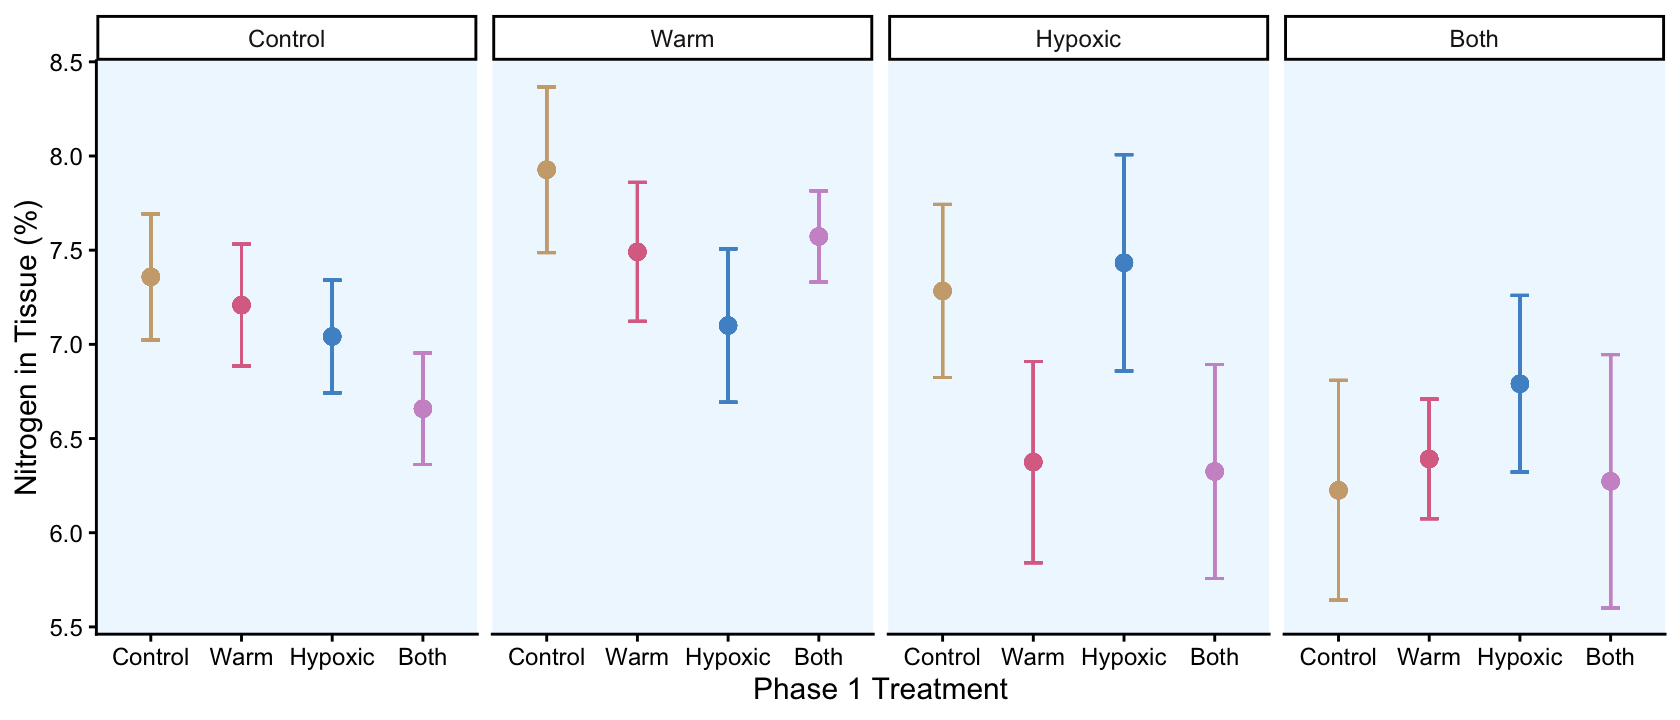

In [12]:
#format for jupyter
options(repr.plot.width = 14, repr.plot.height = 6)

#tissue nitrogen
summary_stats_t <- Tissue_Nitrogen %>%
  group_by(Phase_1_treat, Phase_2_treat) %>%
  mutate(
    mean_growth = mean(wt_percent_n, na.rm = TRUE),
    se_growth = std.error(wt_percent_n, na.rm = TRUE))

#reorder Phase_1_treat and Phase_2_treat
summary_stats_t$Phase_1_treat <- factor(summary_stats_t$Phase_1_treat, 
                                        levels = c("Cont", "Warm","Hyp", "Both"))
summary_stats_t$Phase_2_treat <- factor(summary_stats_t$Phase_2_treat, 
                                        levels = c("Cont", "Warm","Hyp", "Both"))

#plot with mean and SD, TISSUE
ggplot(summary_stats_t, aes(x = Phase_1_treat, y = mean_growth, color = Phase_1_treat)) +
  geom_point(size = 4, position = position_dodge(0.9)) + # Plot means as points
  geom_errorbar(aes(ymin = mean_growth - se_growth, ymax = mean_growth + se_growth), 
                width = 0.2, position = position_dodge(0.9)) + # Error bars for SD
  theme_classic(base_size = 18) +
  guides(color = "none") + # Remove legend for color
  facet_wrap(vars(Phase_2_treat), 
             labeller = as_labeller(c("Hyp" = "Hypoxic", "Cont" = "Control", "Warm" = "Warm", "Both" = "Both")), 
             scales = "fixed", nrow = 1) + # Facet by Phase_2_treat
  scale_color_manual(values = c("Hyp" = "steelblue3", "Warm" = "palevioletred", "Cont" = "burlywood3", "Both" = "plum3")) +
  labs(x = "Phase 1 Treatment", y = "Nitrogen in Tissue (%)") +
  theme(panel.background = element_rect(fill = "aliceblue")) + #fill background light blue
  scale_x_discrete(labels = c("Hyp" = "Hypoxic", "Cont" = "Control", "Warm" = "Warm", "Both" = "Both")) +
  theme(legend.position = "none") # Remove legend

In [13]:
##tissue nitrogen
m1 <- lmer(wt_percent_n~ Phase_1_DO*Phase_1_temp*Phase_2.1_temp*Phase_2.1_DO+
             (1|Phase_2_rep_R)+(1|Phase_1_rep_R)+
             (1|Phase_2_rep_R:Phase_1_DO)+(1|Phase_2_rep_R:Phase_1_temp)+(1|Phase_2_rep_R:Phase_1_DO:Phase_1_temp), data = Tissue_Nitrogen, REML=TRUE)
aov_tab<-Anova(m1, test="F", type="III")

#remove scientific notation
aov_tab %>%
  mutate(`Pr(>F)` = round(`Pr(>F)`, 4))

boundary (singular) fit: see help('isSingular')



,F,Df,Df.res,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),2.426589e+03,1,14.128743,0.0000
Phase_1_DO,3.690382e-01,1,9.444754,0.5579
Phase_1_temp,2.545930e+00,1,9.462947,0.1434
Phase_2.1_temp,1.970548e-03,1,18.965619,0.9651
Phase_2.1_DO,5.419627e+00,1,18.994435,0.0311
Phase_1_DO:Phase_1_temp,2.801160e-02,1,9.460570,0.8706
Phase_1_DO:Phase_2.1_temp,1.018302e-01,1,18.598042,0.7532
Phase_1_temp:Phase_2.1_temp,1.754751e+00,1,18.611492,0.2013
Phase_1_DO:Phase_2.1_DO,1.548781e+00,1,18.672791,0.2287


,Df,F value,Pr(>F)
,<int>,<dbl>,<dbl>
group,15,1.47417,0.1196284
,170,NA,NA


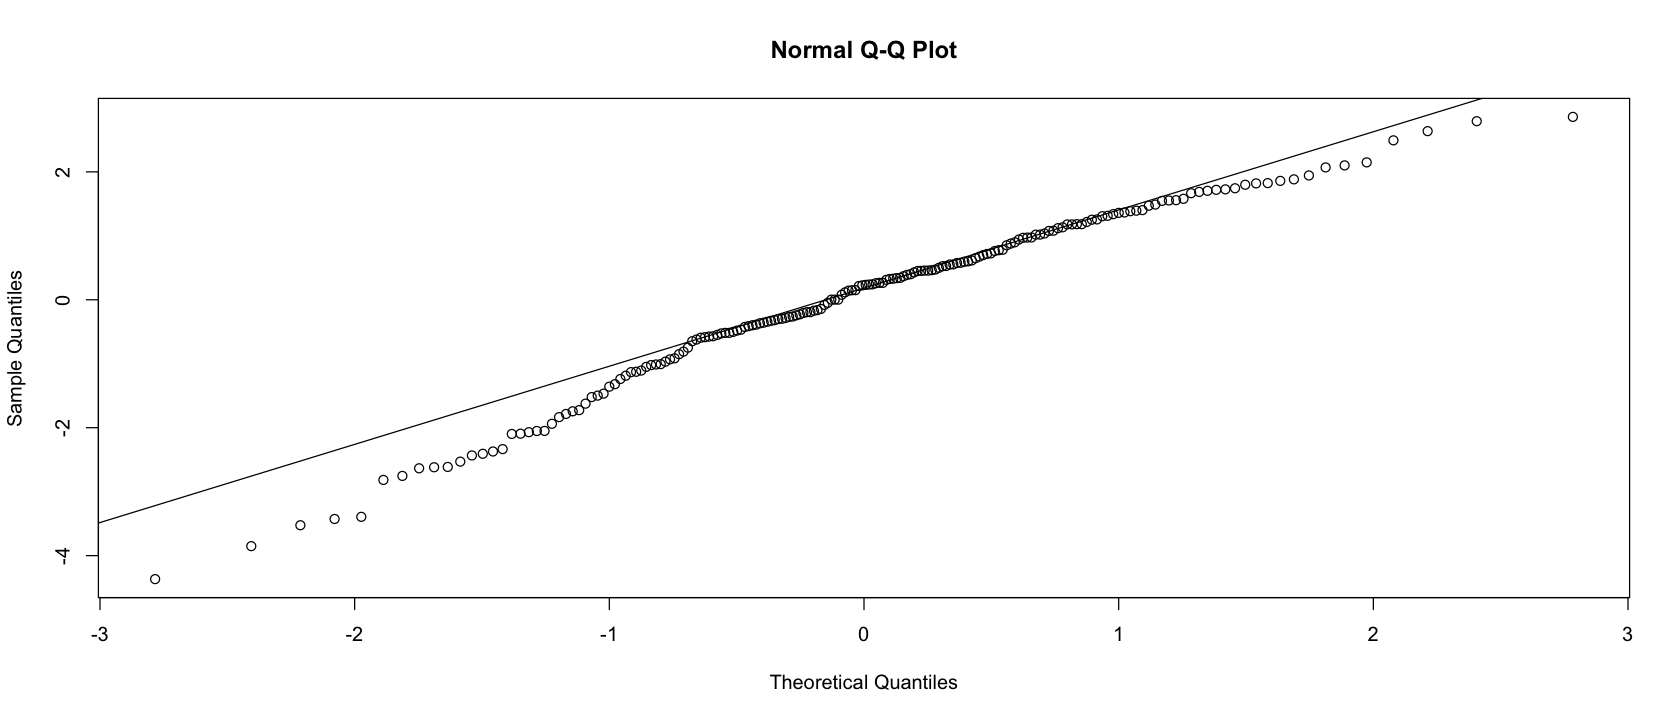

In [11]:
#diagnostics
leveneTest(wt_percent_n~Phase_1_treat*Phase_2_treat, Tissue_Nitrogen) 
m1.e <- residuals(m1) 
qqnorm(m1.e)
qqline(m1.e)

In [15]:
#posthocs
options(width = 120)
emmeans(m1,specs = pairwise ~ Phase_2.1_DO, adjust = "none")

NOTE: Results may be misleading due to involvement in interactions



$emmeans
 Phase_2.1_DO emmean    SE   df lower.CL upper.CL
 Hyp            6.64 0.198 18.0     6.22     7.05
 Norm           7.30 0.203 17.4     6.87     7.72

Results are averaged over the levels of: Phase_1_DO, Phase_1_temp, Phase_2.1_temp 
Degrees-of-freedom method: kenward-roger 
Confidence level used: 0.95 

$contrasts
 contrast   estimate    SE df t.ratio p.value
 Hyp - Norm    -0.66 0.283 19  -2.328  0.0311

Results are averaged over the levels of: Phase_1_DO, Phase_1_temp, Phase_2.1_temp 
Degrees-of-freedom method: kenward-roger 


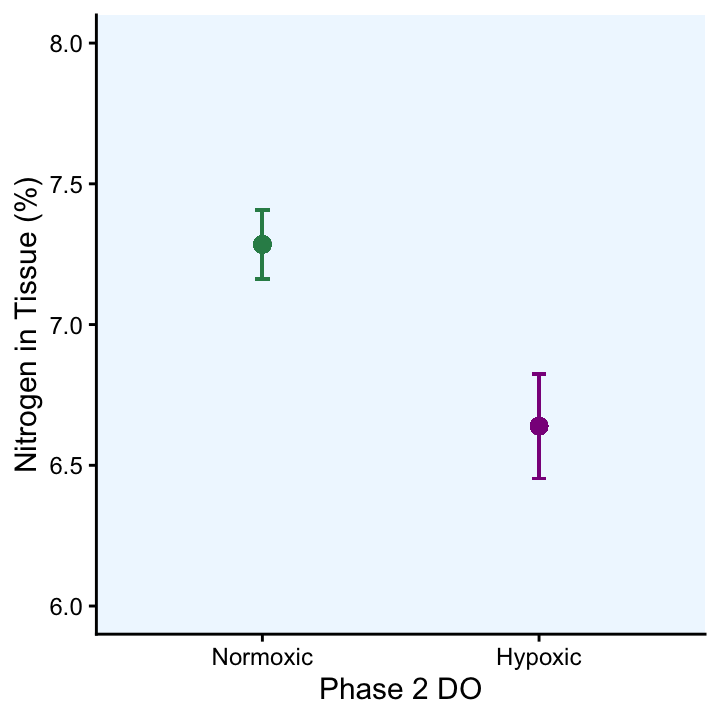

In [16]:
#format for jupyter
options(repr.plot.width = 6, repr.plot.height = 6)

#tissue nitrogen
summary_stats <- Tissue_Nitrogen %>%
  group_by(Phase_2.1_DO) %>%
  mutate(
    mean = mean(wt_percent_n, na.rm = TRUE),
    se = std.error(wt_percent_n, na.rm = TRUE))

#reorder
summary_stats$Phase_2.1_DO <- factor(summary_stats$Phase_2.1_DO, levels = c("Norm", "Hyp"))

#Tissue plot with mean and SD
ggplot(summary_stats, aes(x = Phase_2.1_DO, y = mean, color = Phase_2.1_DO)) +
  geom_point(size = 4, position = position_dodge(0.9)) + # Plot means as points
  geom_errorbar(aes(ymin = mean - se, ymax = mean + se), 
                width = 0.05, position = position_dodge(0.9)) + 
  theme_classic(base_size = 18) +
  theme(panel.background = element_rect(fill = "aliceblue")) + #fill background light blue
  guides(color = "none") + # Remove legend for color
  scale_color_manual(values = c("Hyp" = "darkmagenta", "Norm" = "seagreen")) +
  labs(x = "Phase 2 DO", y = "Nitrogen in Tissue (%)") +
  ylim(6,8)+
  scale_x_discrete(labels = c("Hyp" = "Hypoxic", "Norm" = "Normoxic")) +
  theme(legend.position = "none") # Remove legend

In [50]:
(7.30/6.64)/7.30

[1] 0.1506024

## 2. % Carbon in Tissue

In [17]:
#filter data
Tissue_Carbon <- nutrient_df%>%
filter(Tissue_type == "T") #%>%
#filter(is.na(C_exclude))

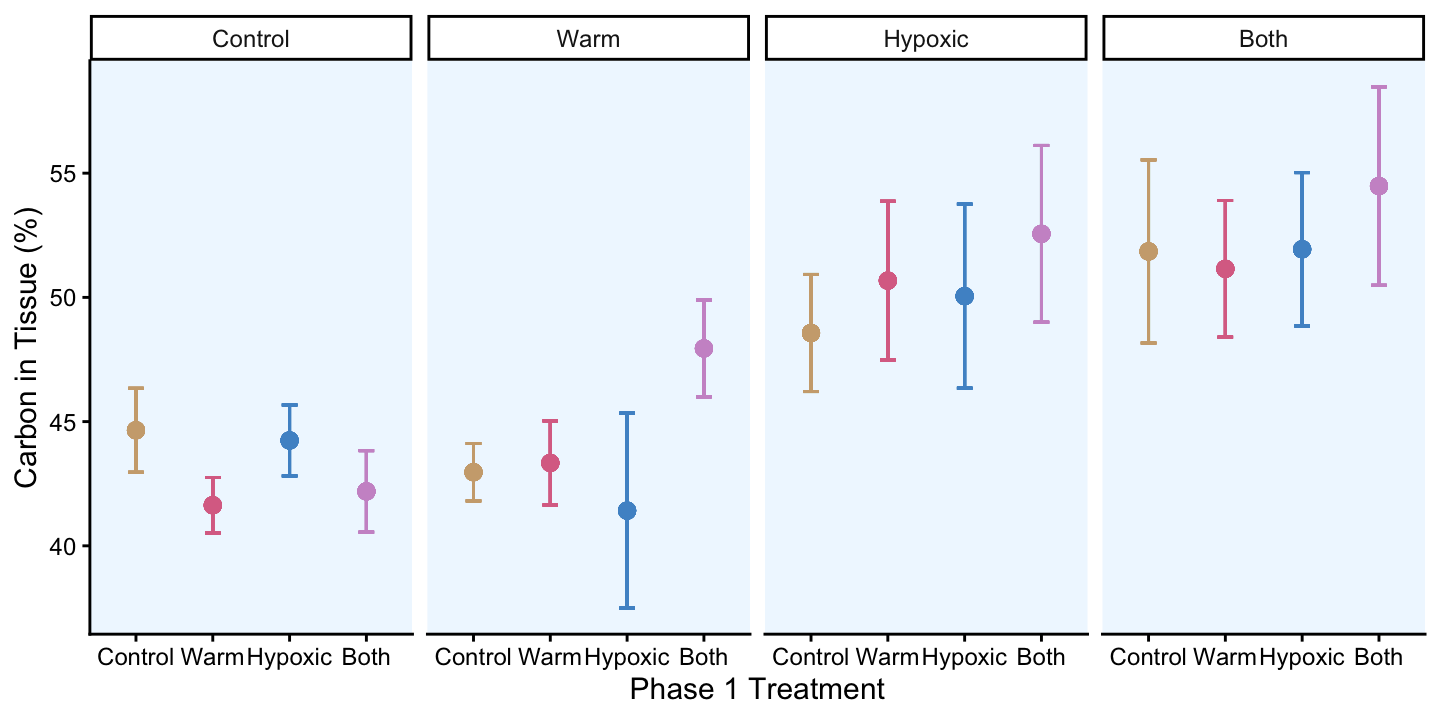

In [18]:
#format for jupyter
options(repr.plot.width = 12, repr.plot.height = 6)

#tissue carbon
summary_stats_t <- Tissue_Carbon %>%
  group_by(Phase_1_treat, Phase_2_treat) %>%
  mutate(
    mean_growth = mean(wt_percent_c, na.rm = TRUE),
    se_growth = std.error(wt_percent_c, na.rm = TRUE))

#reorder Phase_1_treat and Phase_2_treat
summary_stats_t$Phase_1_treat <- factor(summary_stats_t$Phase_1_treat, 
                                        levels = c("Cont", "Warm","Hyp", "Both"))
summary_stats_t$Phase_2_treat <- factor(summary_stats_t$Phase_2_treat, 
                                        levels = c("Cont", "Warm","Hyp", "Both"))

#plot with mean and SD, TISSUE
ggplot(summary_stats_t, aes(x = Phase_1_treat, y = mean_growth, color = Phase_1_treat)) +
  geom_point(size = 4, position = position_dodge(0.9)) + # Plot means as points
  geom_errorbar(aes(ymin = mean_growth - se_growth, ymax = mean_growth + se_growth), 
                width = 0.2, position = position_dodge(0.9)) + # Error bars for SD
  theme_classic(base_size = 18) +
  guides(color = "none") + # Remove legend for color
  facet_wrap(vars(Phase_2_treat), 
             labeller = as_labeller(c("Hyp" = "Hypoxic", "Cont" = "Control", "Warm" = "Warm", "Both" = "Both")), 
             scales = "fixed", nrow = 1) + # Facet by Phase_2_treat
  scale_color_manual(values = c("Hyp" = "steelblue3", "Warm" = "palevioletred", "Cont" = "burlywood3", "Both" = "plum3")) +
  labs(x = "Phase 1 Treatment", y = "Carbon in Tissue (%)") +
  scale_x_discrete(labels = c("Hyp" = "Hypoxic", "Cont" = "Control", "Warm" = "Warm", "Both" = "Both")) +
theme(panel.background = element_rect(fill = "aliceblue")) + #fill background light blue
  theme(legend.position = "none") # Remove legend

In [19]:
##tissue carbon
m2 <- lmer(wt_percent_c~ Phase_1_DO*Phase_1_temp*Phase_2.1_temp*Phase_2.1_DO+
             (1|Phase_2_rep_R)+(1|Phase_1_rep_R)+
             (1|Phase_2_rep_R:Phase_1_DO)+(1|Phase_2_rep_R:Phase_1_temp)+(1|Phase_2_rep_R:Phase_1_DO:Phase_1_temp), data = Tissue_Carbon, REML=TRUE)
aov_tab<-Anova(m2, test="F", type="III")

#remove scientific notation
aov_tab %>%
  mutate(`Pr(>F)` = round(`Pr(>F)`, 4))

boundary (singular) fit: see help('isSingular')



,F,Df,Df.res,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),3.140401e+03,1,13.877055,0.0000
Phase_1_DO,6.115201e-01,1,12.751227,0.4485
Phase_1_temp,5.150442e-01,1,9.464260,0.4903
Phase_2.1_temp,6.652261e-01,1,18.899081,0.4249
Phase_2.1_DO,2.193707e+01,1,18.939262,0.0002
Phase_1_DO:Phase_1_temp,1.001870e+00,1,9.462425,0.3418
Phase_1_DO:Phase_2.1_temp,4.618287e-02,1,18.802428,0.8322
Phase_1_temp:Phase_2.1_temp,5.834032e-01,1,18.559844,0.4546
Phase_1_DO:Phase_2.1_DO,9.169434e-02,1,18.851748,0.7654


In [20]:
#posthocs
options(width = 120)
emmeans(m2,specs = pairwise ~ Phase_2.1_DO, adjust = "none")

NOTE: Results may be misleading due to involvement in interactions



$emmeans
 Phase_2.1_DO emmean   SE   df lower.CL upper.CL
 Hyp            51.4 1.18 18.1     48.9     53.9
 Norm           43.5 1.21 17.3     41.0     46.1

Results are averaged over the levels of: Phase_1_DO, Phase_1_temp, Phase_2.1_temp 
Degrees-of-freedom method: kenward-roger 
Confidence level used: 0.95 

$contrasts
 contrast   estimate   SE   df t.ratio p.value
 Hyp - Norm     7.88 1.68 18.9   4.684  0.0002

Results are averaged over the levels of: Phase_1_DO, Phase_1_temp, Phase_2.1_temp 
Degrees-of-freedom method: kenward-roger 


In [21]:
(51.4-43.5)/51.4

[1] 0.1536965

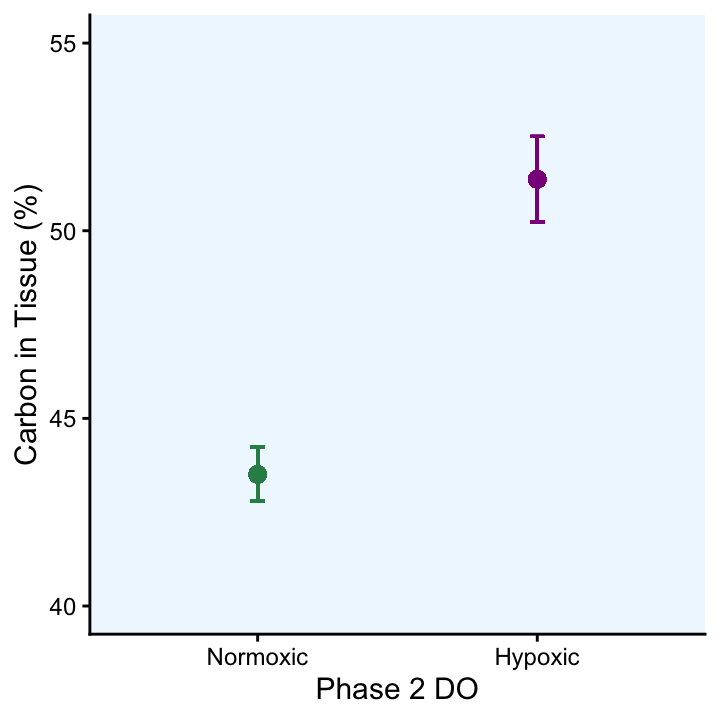

In [25]:
#format for jupyter
options(repr.plot.width = 6, repr.plot.height = 6)

#tissue nitrogen
summary_stats <- Tissue_Carbon %>%
  group_by(Phase_2.1_DO) %>%
  mutate(
    mean = mean(wt_percent_c, na.rm = TRUE),
    se = std.error(wt_percent_c, na.rm = TRUE))

#reorder
summary_stats$Phase_2.1_DO <- factor(summary_stats$Phase_2.1_DO, levels = c("Norm", "Hyp"))

#Tissue plot with mean and SD
ggplot(summary_stats, aes(x = Phase_2.1_DO, y = mean, color = Phase_2.1_DO)) +
  geom_point(size = 4, position = position_dodge(0.9)) + # Plot means as points
  geom_errorbar(aes(ymin = mean - se, ymax = mean + se), 
                width = 0.05, position = position_dodge(0.9)) + 
  theme_classic(base_size = 18) +
  theme(panel.background = element_rect(fill = "aliceblue")) + #fill background light blue
  guides(color = "none") + # Remove legend for color
  scale_color_manual(values = c("Hyp" = "darkmagenta", "Norm" = "seagreen")) +
  labs(x = "Phase 2 DO", y = "Carbon in Tissue (%)") +
  scale_x_discrete(labels = c("Hyp" = "Hypoxic", "Norm" = "Normoxic")) +
ylim(40,55)+
  theme(legend.position = "none") # Remove legend

,Df,F value,Pr(>F)
,<int>,<dbl>,<dbl>
group,15,1.8094,0.0366876
,171,NA,NA


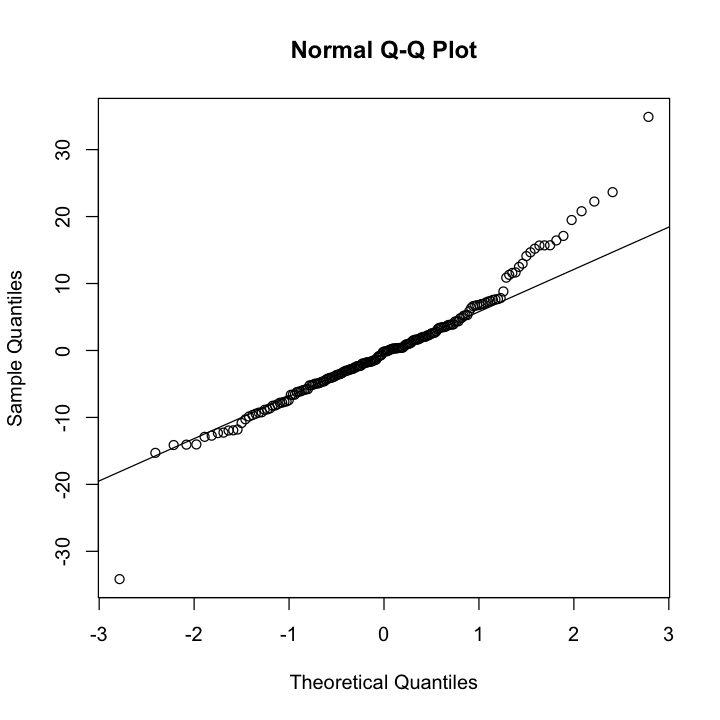

In [26]:
#diagnostics
leveneTest(wt_percent_c~Phase_1_treat*Phase_2_treat, Tissue_Carbon)
m1.e <- residuals(m2) 
qqnorm(m1.e)
qqline(m1.e)

## 3. Carbon:Nitrogen in Tissue

In [29]:
#filter data
Tissue_CN <- nutrient_df%>%
filter(Tissue_type == "T")%>%
filter(is.na(N_Exclude)) #%>%
#filter(is.na(c_exclude))

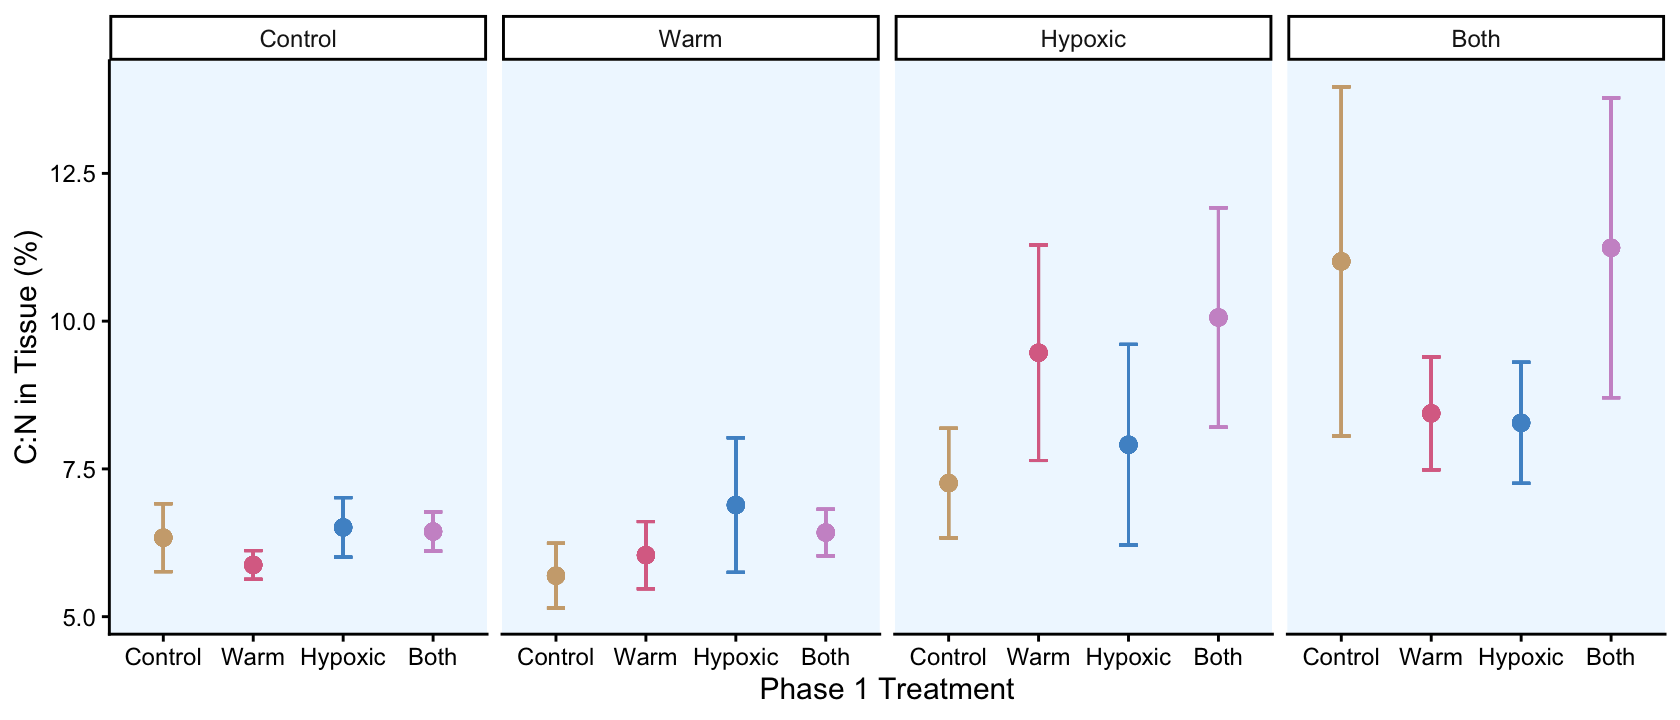

In [30]:
#format for jupyter
options(repr.plot.width = 14, repr.plot.height = 6)

#tissue c:n
summary_stats_t <- Tissue_CN %>%
  group_by(Phase_1_treat, Phase_2_treat) %>%
  mutate(
    mean_growth = mean((wt_percent_c/wt_percent_n), na.rm = TRUE),
    se_growth = std.error((wt_percent_c/wt_percent_n), na.rm = TRUE))

#reorder Phase_1_treat and Phase_2_treat
summary_stats_t$Phase_1_treat <- factor(summary_stats_t$Phase_1_treat, 
                                        levels = c("Cont", "Warm","Hyp", "Both"))
summary_stats_t$Phase_2_treat <- factor(summary_stats_t$Phase_2_treat, 
                                        levels = c("Cont", "Warm","Hyp", "Both"))

#plot with mean and SD, TISSUE
ggplot(summary_stats_t, aes(x = Phase_1_treat, y = mean_growth, color = Phase_1_treat)) +
  geom_point(size = 4, position = position_dodge(0.9)) + # Plot means as points
  geom_errorbar(aes(ymin = mean_growth - se_growth, ymax = mean_growth + se_growth), 
                width = 0.2, position = position_dodge(0.9)) + # Error bars for SD
  theme_classic(base_size = 18) +
  guides(color = "none") + # Remove legend for color
  facet_wrap(vars(Phase_2_treat), 
             labeller = as_labeller(c("Hyp" = "Hypoxic", "Cont" = "Control", "Warm" = "Warm", "Both" = "Both")), 
             scales = "fixed", nrow = 1) + # Facet by Phase_2_treat
  scale_color_manual(values = c("Hyp" = "steelblue3", "Warm" = "palevioletred", "Cont" = "burlywood3", "Both" = "plum3")) +
  labs(x = "Phase 1 Treatment", y = "C:N in Tissue (%)") +
  scale_x_discrete(labels = c("Hyp" = "Hypoxic", "Cont" = "Control", "Warm" = "Warm", "Both" = "Both")) +
theme(panel.background = element_rect(fill = "aliceblue")) + #fill background light blue
  theme(legend.position = "none") # Remove legend

In [56]:
##tissue carbon:nitrogen
    #log transform to pass levene test, results are the same
m3 <- lmer((wt_percent_c/wt_percent_n)~ Phase_1_DO*Phase_1_temp*Phase_2.1_temp*Phase_2.1_DO+
             (1|Phase_2_rep_R)+(1|Phase_1_rep_R)+
             (1|Phase_2_rep_R:Phase_1_DO)+(1|Phase_2_rep_R:Phase_1_temp)+(1|Phase_2_rep_R:Phase_1_DO:Phase_1_temp), data = Tissue_CN, REML=TRUE)
aov_tab<-Anova(m3, test="F", type="III")

#remove scientific notation
aov_tab %>%
  mutate(`Pr(>F)` = round(`Pr(>F)`, 4))

boundary (singular) fit: see help('isSingular')



,F,Df,Df.res,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),3.951927e+02,1,11.990021,0.0000
Phase_1_DO,3.672268e-01,1,11.174214,0.5566
Phase_1_temp,5.114462e-01,1,9.470198,0.4918
Phase_2.1_temp,4.590007e-01,1,18.794988,0.5063
Phase_2.1_DO,1.411845e+01,1,18.841045,0.0013
Phase_1_DO:Phase_1_temp,8.529164e-01,1,9.469784,0.3787
Phase_1_DO:Phase_2.1_temp,4.216433e-03,1,18.732559,0.9489
Phase_1_temp:Phase_2.1_temp,4.762592e-01,1,18.617736,0.4986
Phase_1_DO:Phase_2.1_DO,2.554223e-02,1,18.786624,0.8747


In [57]:
#posthocs
options(width = 120)
emmeans(m3,specs = pairwise ~ Phase_2.1_DO, adjust = "none")

NOTE: Results may be misleading due to involvement in interactions



$emmeans
 Phase_2.1_DO emmean    SE   df lower.CL upper.CL
 Hyp            9.21 0.545 17.3     8.06    10.36
 Norm           6.28 0.558 16.3     5.10     7.46

Results are averaged over the levels of: Phase_1_DO, Phase_1_temp, Phase_2.1_temp 
Degrees-of-freedom method: kenward-roger 
Results are given on the ( (not the response) scale. 
Confidence level used: 0.95 

$contrasts
 contrast   estimate   SE   df t.ratio p.value
 Hyp - Norm     2.93 0.78 18.8   3.757  0.0013

Results are averaged over the levels of: Phase_1_DO, Phase_1_temp, Phase_2.1_temp 
Note: contrasts are still on the ( scale. Consider using
      regrid() if you want contrasts of back-transformed estimates. 
Degrees-of-freedom method: kenward-roger 


In [34]:
(9.21-6.28)/9.21

[1] 0.3181325

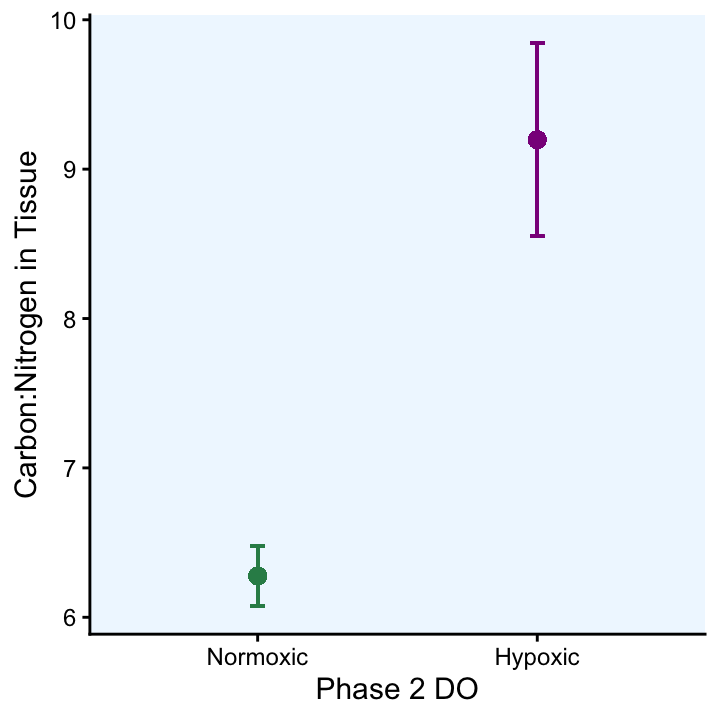

In [47]:
#format for jupyter
options(repr.plot.width = 6, repr.plot.height = 6)

#tissue nitrogen
summary_stats <- Tissue_CN %>%
  group_by(Phase_2.1_DO) %>%
  mutate(
    mean = mean((wt_percent_c/wt_percent_n), na.rm = TRUE),
    se = std.error((wt_percent_c/wt_percent_n), na.rm = TRUE))

#reorder
summary_stats$Phase_2.1_DO <- factor(summary_stats$Phase_2.1_DO, levels = c("Norm", "Hyp"))

#Tissue plot with mean and SD
ggplot(summary_stats, aes(x = Phase_2.1_DO, y = mean, color = Phase_2.1_DO)) +
  geom_point(size = 4, position = position_dodge(0.9)) + # Plot means as points
  geom_errorbar(aes(ymin = mean - se, ymax = mean + se), 
                width = 0.05, position = position_dodge(0.9)) + 
  theme_classic(base_size = 18) +
  theme(panel.background = element_rect(fill = "aliceblue")) + #fill background light blue
  guides(color = "none") + # Remove legend for color
  scale_color_manual(values = c("Hyp" = "darkmagenta", "Norm" = "seagreen")) +
  labs(x = "Phase 2 DO", y = "Carbon:Nitrogen in Tissue") +
  scale_x_discrete(labels = c("Hyp" = "Hypoxic", "Norm" = "Normoxic")) +
  theme(legend.position = "none") # Remove legend

,Df,F value,Pr(>F)
,<int>,<dbl>,<dbl>
group,15,1.805042,0.03734251
,170,NA,NA


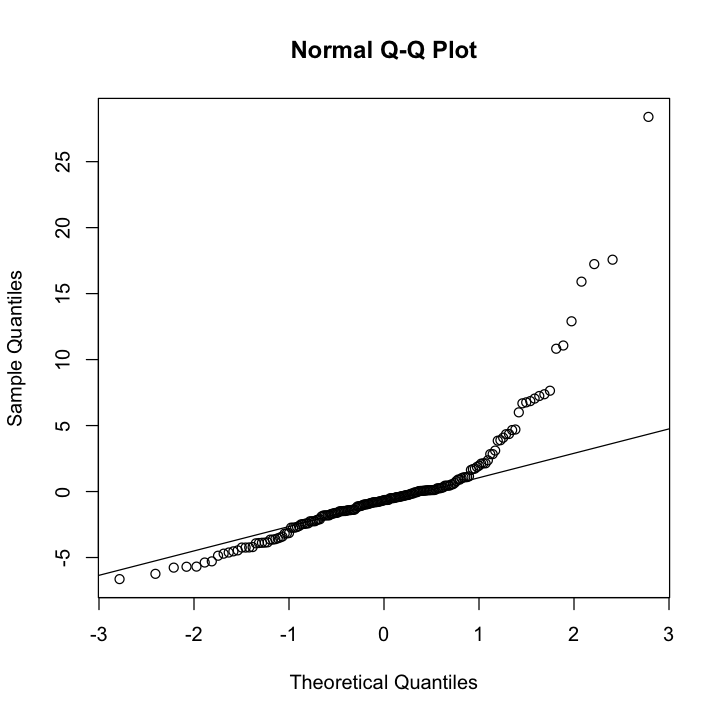

In [58]:
#diagnostics
leveneTest((wt_percent_c/wt_percent_n)~Phase_1_treat*Phase_2_treat, Tissue_CN) 
m1.e <- residuals(m3)
qqnorm(m1.e)
qqline(m1.e)

## 4. Mg Carbon and Nitrogen in Tissue

In [61]:
# Read in growth dataset
setwd("/Users/sophiemontague/Desktop/MontagueORCC_repo/MontagueORCC")
weight_df <- read_csv("Year_2_Data/growth_YEAR2_weights_merged.csv")

New names:
• `` -> `...1`
Rows: 572 Columns: 45
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (22): Sample_Name, Phase_1_DO, Phase_1_temp, Phase_2.1_DO, Phase_2.1_temp, Phase_1_treat, Phase_2_treat, Phase_1...
dbl (23): ...1, Actual_shell_pre_mg, Actual_tissue_pre_mg, Actual_shell_post_mg, Actual_tissue_post_mg, Actual_shell...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [62]:
#calculate % N averages Tissue

summary_stats_t <- Tissue_CN %>%
  group_by(Phase_1_treat, Phase_2_treat) %>%
  summarize(
    mean_N = mean(wt_percent_n, na.rm = TRUE),
    mean_C = mean(wt_percent_c, na.rm = TRUE))

print(summary_stats_t)

`summarise()` has regrouped the output.
ℹ Summaries were computed grouped by Phase_1_treat and Phase_2_treat.
ℹ Output is grouped by Phase_1_treat.
ℹ Use `summarise(.groups = "drop_last")` to silence this message.
ℹ Use `summarise(.by = c(Phase_1_treat, Phase_2_treat))` for per-operation
  grouping (`?dplyr::dplyr_by`) instead.


# A tibble: 16 × 4
# Groups:   Phase_1_treat [4]
   Phase_1_treat Phase_2_treat mean_N mean_C
   <chr>         <chr>          <dbl>  <dbl>
 1 Both          Both            6.27   54.5
 2 Both          Cont            6.66   42.2
 3 Both          Hyp             6.32   52.6
 4 Both          Warm            7.57   47.9
 5 Cont          Both            6.22   51.8
 6 Cont          Cont            7.36   44.6
 7 Cont          Hyp             7.28   48.6
 8 Cont          Warm            7.93   43.0
 9 Hyp           Both            6.79   51.9
10 Hyp           Cont            7.04   44.2
11 Hyp           Hyp             7.43   50.0
12 Hyp           Warm            7.1    44.7
13 Warm          Both            6.39   51.2
14 Warm          Cont            7.21   41.6
15 Warm          Hyp             6.38   50.7
16 Warm          Warm            7.49   43.3


In [64]:
Tissue_Nutrients <- weight_df %>%
  filter(Exclude_year2 != "Y" | is.na(Exclude_year2)) %>%
  left_join(
    summary_stats_t,
    by = c("Phase_1_treat", "Phase_2_treat")) %>%
  mutate(mgN_tissue_P2 = (Actual_tissue_post_mg * mean_N) / 100)%>%
  mutate(mgC_tissue_P2 = (Actual_tissue_post_mg * mean_C) / 100)

View(Tissue_Nutrients)

...1,Sample_Name,Phase_1_DO,Phase_1_temp,Phase_2.1_DO,Phase_2.1_temp,Phase_1_treat,Phase_2_treat,Phase_1_rep_R,Phase_2_rep_R,⋯,Actual_shell_year2_mg,Actual_tissue_year2_mg,Actual_shell_growth_year2_mg,Actual_tissue_growth_year2_mg,Ratio_TS_year2,Exclude_year2,mean_N,mean_C,mgN_tissue_P2,mgC_tissue_P2
<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
2,2024_Both01_Both02_O14,Hyp,Warm,Hyp,Warm,Both,Both,Both01,Both02,⋯,816.4478,492.8522,161.0318,125.96822,0.7822569,NA,6.272727,54.48182,23.013629,199.88504
3,2024_Both01_Both03_O26,Hyp,Warm,Hyp,Warm,Both,Both,Both01,Both03,⋯,1259.9582,568.7418,799.4587,368.54134,0.4609886,NA,6.272727,54.48182,12.558030,109.07286
4,2024_Both01_Both05_O49,Hyp,Warm,Hyp,Warm,Both,Both,Both01,Both05,⋯,1147.8535,663.6465,529.3306,334.26938,0.6314945,NA,6.272727,54.48182,20.660931,179.45067
5,2024_Both01_Both05_O50,Hyp,Warm,Hyp,Warm,Both,Both,Both01,Both05,⋯,1147.5368,535.0632,437.3351,181.36492,0.4147047,NA,6.272727,54.48182,22.186530,192.70126
6,2024_Both01_Both06_O61,Hyp,Warm,Hyp,Warm,Both,Both,Both01,Both06,⋯,545.8448,253.7552,254.6107,57.48928,0.2257928,NA,6.272727,54.48182,12.311227,106.92925
8,2024_Both01_Cont02_O13,Hyp,Warm,Norm,Ambient,Both,Cont,Both01,Cont02,⋯,2070.5006,1038.7994,929.1391,566.36088,0.6095544,NA,6.658333,42.19167,31.456529,199.32967
9,2024_Both01_Cont02_O14,Hyp,Warm,Norm,Ambient,Both,Cont,Both01,Cont02,⋯,4832.5836,3211.7164,3032.6860,1994.11398,0.6575405,NA,6.658333,42.19167,81.072028,513.72675
10,2024_Both01_Cont04_O38,Hyp,Warm,Norm,Ambient,Both,Cont,Both01,Cont04,⋯,1287.8260,648.7740,688.9373,283.26266,0.4111588,NA,6.658333,42.19167,24.336962,154.21532
11,2024_Both01_Cont06_O61,Hyp,Warm,Norm,Ambient,Both,Cont,Both01,Cont06,⋯,2624.2156,1127.1844,2162.7661,873.53394,0.4038966,NA,6.658333,42.19167,16.888892,107.01935


### 4.1 Mg Nitrogen Analysis

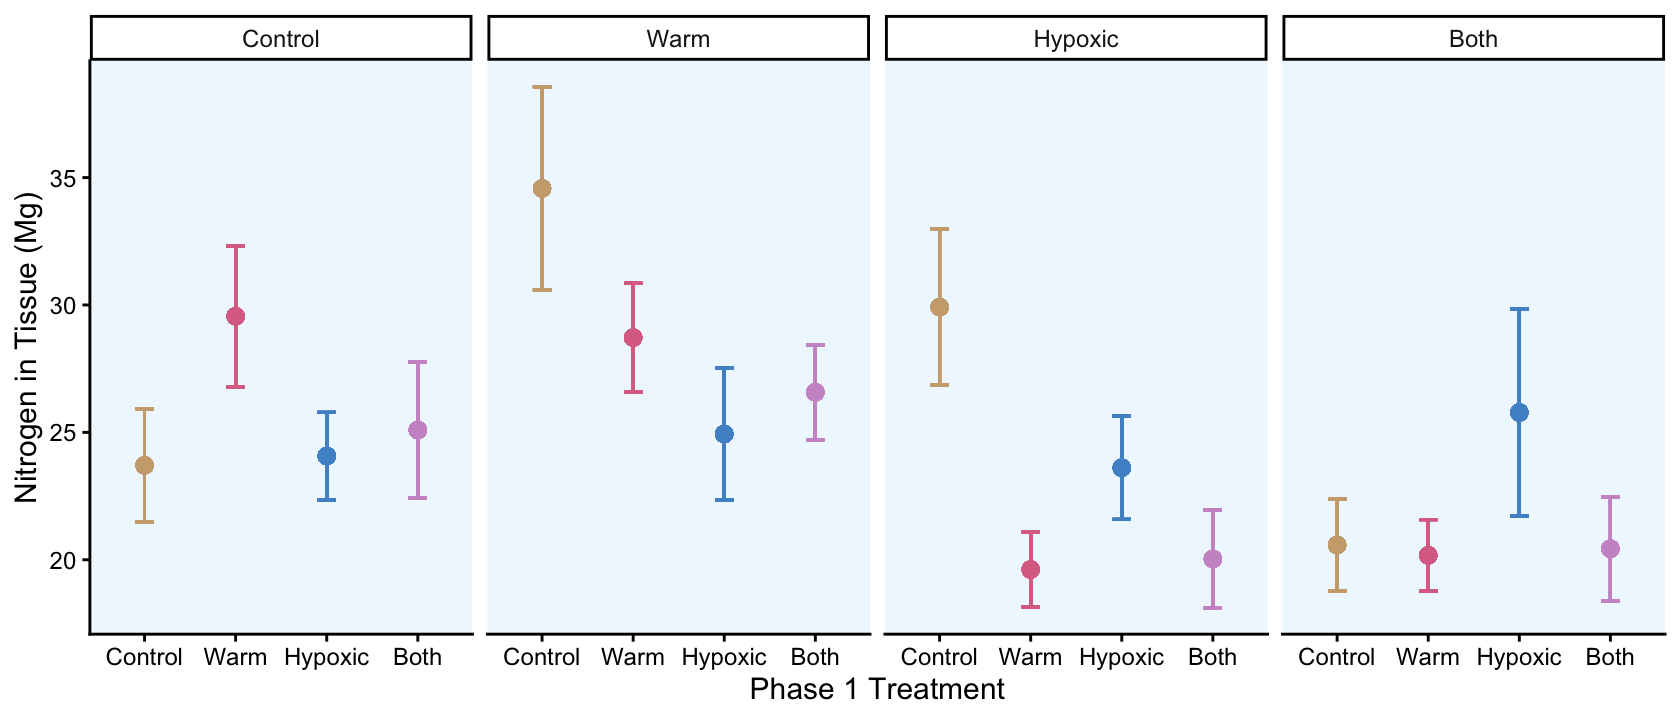

In [82]:
#format for jupyter
options(repr.plot.width = 14, repr.plot.height = 6)

#tissue nitrogen
summary_stats_t <- Tissue_Nutrients %>%
  group_by(Phase_1_treat, Phase_2_treat) %>%
  mutate(
    mean_growth = mean(mgN_tissue_P2, na.rm = TRUE),
    se_growth = std.error(mgN_tissue_P2, na.rm = TRUE))

#reorder Phase_1_treat and Phase_2_treat
summary_stats_t$Phase_1_treat <- factor(summary_stats_t$Phase_1_treat, 
                                        levels = c("Cont", "Warm","Hyp", "Both"))
summary_stats_t$Phase_2_treat <- factor(summary_stats_t$Phase_2_treat, 
                                        levels = c("Cont", "Warm","Hyp", "Both"))

#plot with mean and SD, TISSUE
ggplot(summary_stats_t, aes(x = Phase_1_treat, y = mean_growth, color = Phase_1_treat)) +
  geom_point(size = 4, position = position_dodge(0.9)) + # Plot means as points
  geom_errorbar(aes(ymin = mean_growth - se_growth, ymax = mean_growth + se_growth), 
                width = 0.2, position = position_dodge(0.9)) + # Error bars for SD
  theme_classic(base_size = 18) +
  guides(color = "none") + # Remove legend for color
  facet_wrap(vars(Phase_2_treat), 
             labeller = as_labeller(c("Hyp" = "Hypoxic", "Cont" = "Control", "Warm" = "Warm", "Both" = "Both")), 
             scales = "fixed", nrow = 1) + # Facet by Phase_2_treat
  scale_color_manual(values = c("Hyp" = "steelblue3", "Warm" = "palevioletred", "Cont" = "burlywood3", "Both" = "plum3")) +
  labs(x = "Phase 1 Treatment", y = "Nitrogen in Tissue (Mg)") +
  scale_x_discrete(labels = c("Hyp" = "Hypoxic", "Cont" = "Control", "Warm" = "Warm", "Both" = "Both")) +
  theme(panel.background = element_rect(fill = "aliceblue")) + #fill background light blue
  theme(legend.position = "none") # Remove legend

In [71]:
##tissue nitrogen
m1 <- lmer(log(mgN_tissue_P2)~ Phase_1_DO*Phase_1_temp*Phase_2.1_temp*Phase_2.1_DO+
             (1|Phase_2_rep_R)+(1|Phase_1_rep_R)+
             (1|Phase_2_rep_R:Phase_1_DO)+(1|Phase_2_rep_R:Phase_1_temp)+(1|Phase_2_rep_R:Phase_1_DO:Phase_1_temp), data = Tissue_Nutrients, REML=TRUE)
aov_tab<-Anova(m1, test="F", type="III")

#remove scientific notation
aov_tab %>%
  mutate(`Pr(>F)` = round(`Pr(>F)`, 4))

boundary (singular) fit: see help('isSingular')



,F,Df,Df.res,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),4.033926e+03,1,22.93804,0.0000
Phase_1_DO,1.902932e+00,1,17.56705,0.1851
Phase_1_temp,1.078816e+00,1,14.77118,0.3157
Phase_2.1_temp,4.619757e-03,1,19.46234,0.9465
Phase_2.1_DO,4.721941e+00,1,19.50622,0.0423
Phase_1_DO:Phase_1_temp,5.499888e-03,1,14.35199,0.9419
Phase_1_DO:Phase_2.1_temp,9.227149e-03,1,18.70529,0.9245
Phase_1_temp:Phase_2.1_temp,5.701201e-01,1,18.48061,0.4597
Phase_1_DO:Phase_2.1_DO,6.008992e-01,1,18.80955,0.4479


In [74]:
#posthocs
options(width = 120)
emmeans(m1,specs = pairwise ~ Phase_2.1_DO, adjust = "none")

NOTE: Results may be misleading due to involvement in interactions



$emmeans
 Phase_2.1_DO emmean     SE   df lower.CL upper.CL
 Hyp            2.99 0.0656 21.7     2.85     3.12
 Norm           3.18 0.0672 22.1     3.05     3.32

Results are averaged over the levels of: Phase_1_DO, Phase_1_temp, Phase_2.1_temp 
Degrees-of-freedom method: kenward-roger 
Results are given on the log (not the response) scale. 
Confidence level used: 0.95 

$contrasts
 contrast   estimate     SE   df t.ratio p.value
 Hyp - Norm   -0.197 0.0905 19.5  -2.173  0.0423

Results are averaged over the levels of: Phase_1_DO, Phase_1_temp, Phase_2.1_temp 
Degrees-of-freedom method: kenward-roger 
Results are given on the log (not the response) scale. 


In [81]:
(3.18 - 2.99)/3.18

[1] 0.05974843

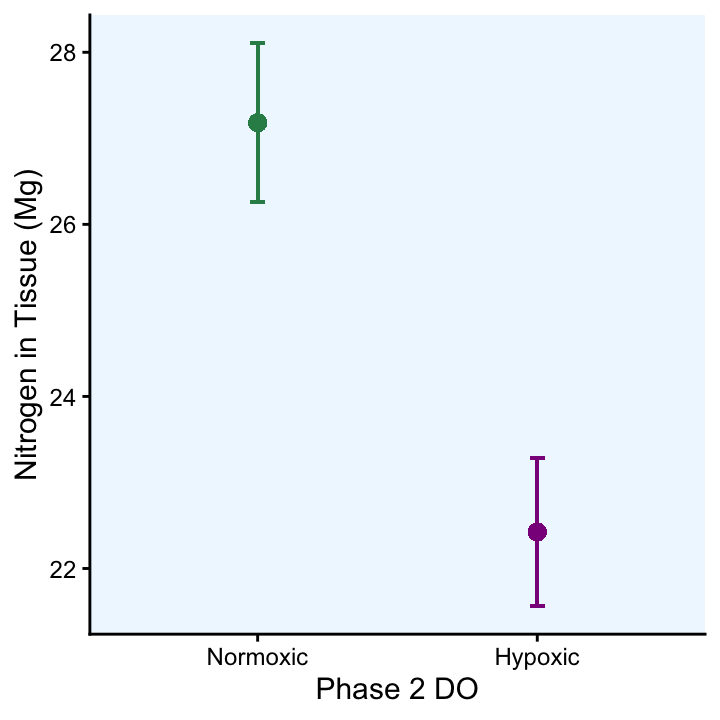

In [75]:
#format for jupyter
options(repr.plot.width = 6, repr.plot.height = 6)

#tissue nitrogen
summary_stats <- Tissue_Nutrients %>%
  group_by(Phase_2.1_DO) %>%
  mutate(
    mean = mean(mgN_tissue_P2, na.rm = TRUE),
    se = std.error(mgN_tissue_P2, na.rm = TRUE))

#reorder
summary_stats$Phase_2.1_DO <- factor(summary_stats$Phase_2.1_DO, levels = c("Norm", "Hyp"))

#Tissue plot with mean and SD
ggplot(summary_stats, aes(x = Phase_2.1_DO, y = mean, color = Phase_2.1_DO)) +
  geom_point(size = 4, position = position_dodge(0.9)) + # Plot means as points
  geom_errorbar(aes(ymin = mean - se, ymax = mean + se), 
                width = 0.05, position = position_dodge(0.9)) + 
  theme_classic(base_size = 18) +
  theme(panel.background = element_rect(fill = "aliceblue")) + #fill background light blue
  guides(color = "none") + # Remove legend for color
  scale_color_manual(values = c("Hyp" = "darkmagenta", "Norm" = "seagreen")) +
  labs(x = "Phase 2 DO", y = "Nitrogen in Tissue (Mg)") +
  scale_x_discrete(labels = c("Hyp" = "Hypoxic", "Norm" = "Normoxic")) +
  theme(legend.position = "none") # Remove legend

In [73]:
#posthocs
options(width = 120)
emmeans(m1,specs = pairwise ~ Phase_1_DO:Phase_1_temp:Phase_2.1_temp:Phase_2.1_DO, adjust = "none")

$emmeans
 Phase_1_DO Phase_1_temp Phase_2.1_temp Phase_2.1_DO emmean    SE   df lower.CL upper.CL
 Hyp        Ambient      Ambient        Hyp            3.07 0.126 56.1     2.81     3.32
 Norm       Ambient      Ambient        Hyp            3.24 0.124 54.4     2.99     3.49
 Hyp        Warm         Ambient        Hyp            2.88 0.122 51.2     2.63     3.12
 Norm       Warm         Ambient        Hyp            2.92 0.122 51.3     2.68     3.17
 Hyp        Ambient      Warm           Hyp            3.03 0.121 49.8     2.78     3.27
 Norm       Ambient      Warm           Hyp            2.93 0.120 47.4     2.69     3.17
 Hyp        Warm         Warm           Hyp            2.89 0.120 48.5     2.65     3.13
 Norm       Warm         Warm           Hyp            2.95 0.123 52.8     2.70     3.20
 Hyp        Ambient      Ambient        Norm           3.13 0.125 51.0     2.88     3.38
 Norm       Ambient      Ambient        Norm           3.07 0.134 60.6     2.81     3.34
 Hyp        

In [ ]:
        cont warm comparisons:
Hyp Ambient Warm Norm - Norm Ambient Warm Norm        -9.6803 4.37 40.2  -2.215  0.0325
    hyp warm - cont warm
Norm Ambient Ambient Norm - Norm Ambient Warm Norm   -11.0574 5.23 61.7  -2.114  0.0385
    cont cont - cont warm
Norm Warm Warm Hyp - Norm Ambient Warm Norm          -13.9855 5.17 61.8  -2.705  0.0088
    warm both - cont warm
Hyp Warm Warm Hyp - Norm Ambient Warm Norm           -13.7876 5.12 59.6  -2.695  0.0091
    both both - cont warm
Norm Ambient Warm Hyp - Norm Ambient Warm Norm       -13.9494 4.94 56.0  -2.825  0.0065
    cont both - cont warm
Norm Warm Ambient Hyp - Norm Ambient Warm Norm       -14.3652 5.15 61.0  -2.790  0.0070
    warm hyp - cont warm
Hyp Warm Ambient Hyp - Norm Ambient Warm Norm        -14.7909 5.14 60.9  -2.876  0.0055
    both hyp - cont warm
Hyp Ambient Ambient Hyp - Norm Ambient Warm Norm     -11.0441 5.22 63.6  -2.116  0.0383
    hyp hyp - cont warm

Norm Ambient Ambient Hyp - Hyp Warm Ambient Hyp        9.2708 4.41 41.7   2.102  0.0416
    cont hyp - both hyp
Norm Ambient Ambient Hyp - Norm Warm Ambient Hyp       8.8452 4.02 43.2   2.198  0.0334
    cont hyp - warm hyp   interesting !


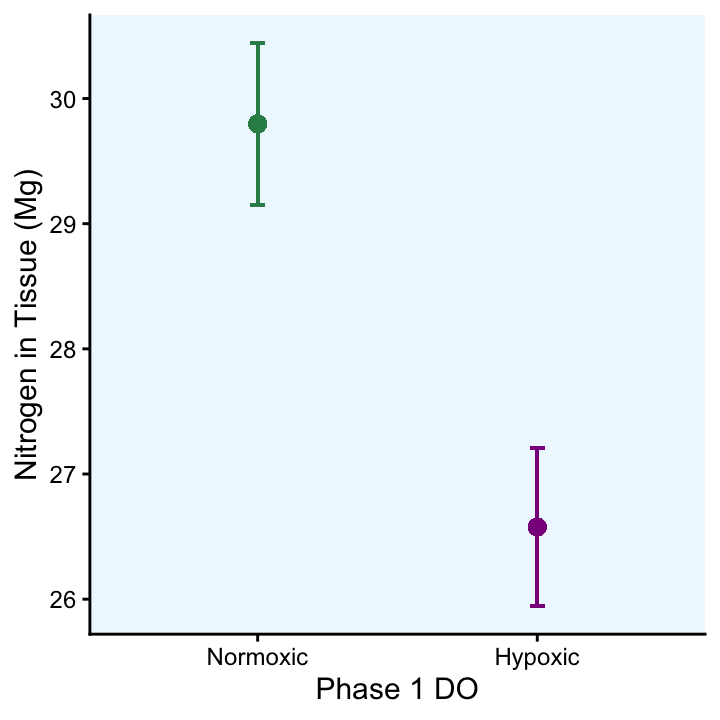

In [317]:
#format for jupyter
options(repr.plot.width = 6, repr.plot.height = 6)

#tissue nitrogen
summary_stats <- Tissue_Nutrients %>%
  group_by(Phase_1_DO) %>%
  mutate(
    mean = mean(mgN_tissue_P2, na.rm = TRUE),
    se = std.error(mgN_tissue_P2, na.rm = TRUE))

#reorder
summary_stats$Phase_1_DO <- factor(summary_stats$Phase_1_DO, levels = c("Norm", "Hyp"))

#Tissue plot with mean and SD
ggplot(summary_stats, aes(x = Phase_1_DO, y = mean, color = Phase_1_DO)) +
  geom_point(size = 4, position = position_dodge(0.9)) + # Plot means as points
  geom_errorbar(aes(ymin = mean - se, ymax = mean + se), 
                width = 0.05, position = position_dodge(0.9)) + 
  theme_classic(base_size = 18) +
  theme(panel.background = element_rect(fill = "aliceblue")) + #fill background light blue
  guides(color = "none") + # Remove legend for color
  scale_color_manual(values = c("Hyp" = "darkmagenta", "Norm" = "seagreen")) +
  labs(x = "Phase 1 DO", y = "Nitrogen in Tissue (Mg)") +
  scale_x_discrete(labels = c("Hyp" = "Hypoxic", "Norm" = "Normoxic")) +
  theme(legend.position = "none") # Remove legend

In [83]:
#posthocs
options(width = 120)
emmeans(m1,specs = pairwise ~ Phase_1_temp:Phase_2.1_DO, adjust = "none")

NOTE: Results may be misleading due to involvement in interactions



$emmeans
 Phase_1_temp Phase_2.1_DO emmean     SE   df lower.CL upper.CL
 Ambient      Hyp            3.07 0.0743 31.0     2.91     3.22
 Warm         Hyp            2.91 0.0738 30.5     2.76     3.06
 Ambient      Norm           3.16 0.0761 31.8     3.01     3.32
 Warm         Norm           3.21 0.0752 30.5     3.05     3.36

Results are averaged over the levels of: Phase_1_DO, Phase_2.1_temp 
Degrees-of-freedom method: kenward-roger 
Results are given on the log (not the response) scale. 
Confidence level used: 0.95 

$contrasts
 contrast                   estimate     SE   df t.ratio p.value
 Ambient Hyp - Warm Hyp       0.1552 0.0686 20.7   2.262  0.0346
 Ambient Hyp - Ambient Norm  -0.0985 0.1000 27.9  -0.981  0.3348
 Ambient Hyp - Warm Norm     -0.1398 0.1060 30.8  -1.322  0.1959
 Warm Hyp - Ambient Norm     -0.2537 0.1060 31.2  -2.393  0.0229
 Warm Hyp - Warm Norm        -0.2950 0.0993 26.9  -2.972  0.0062
 Ambient Norm - Warm Norm    -0.0413 0.0695 20.4  -0.594  0.5590

Result

In [84]:
(3.07 -2.91)/3.07

[1] 0.05211726

In [85]:
(3.16-2.91)/3.16

[1] 0.07911392

In [86]:
(3.21-2.91)/3.21

[1] 0.09345794

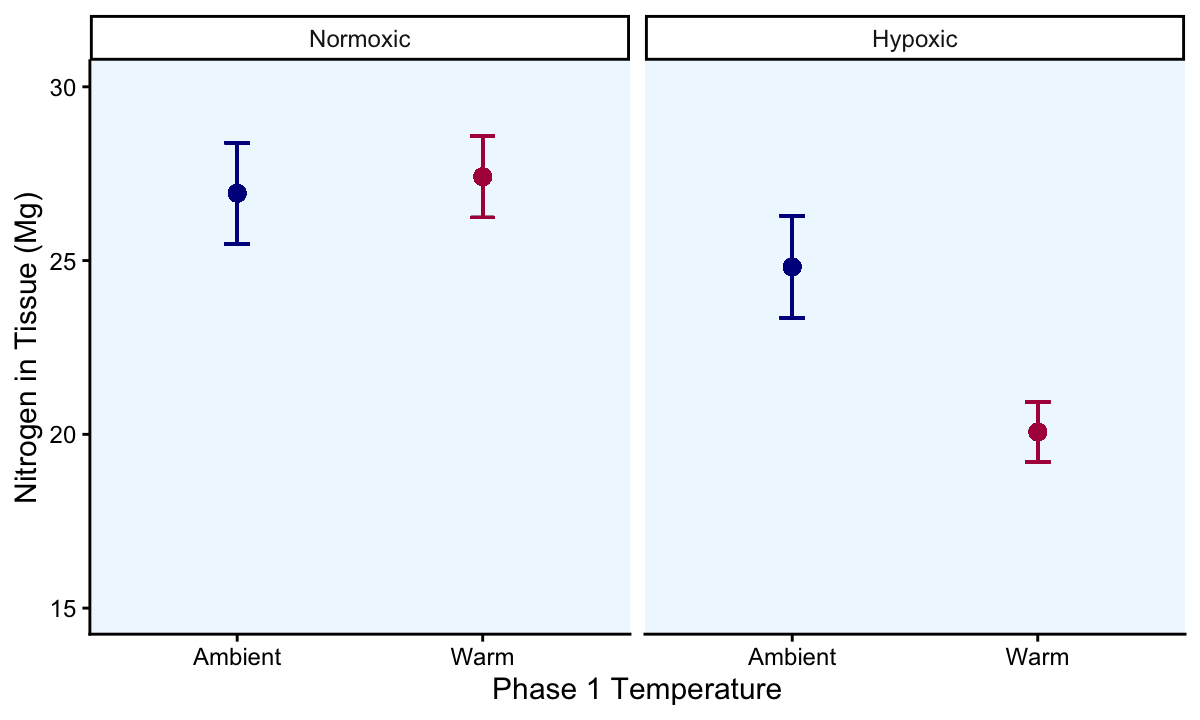

In [80]:
#format for jupyter
options(repr.plot.width = 10, repr.plot.height = 6)

#tissue nitrogen Phase_1_temp:Phase_2.1_DO
summary_stats_t <- Tissue_Nutrients %>%
  group_by(Phase_1_temp, Phase_2.1_DO) %>%
  mutate(
    mean = mean(mgN_tissue_P2, na.rm = TRUE),
    se = std.error(mgN_tissue_P2, na.rm = TRUE))

#reorder Phase_1_treat and Phase_2_treat
summary_stats_t$Phase_1_temp <- factor(summary_stats_t$Phase_1_temp, 
                                        levels = c("Ambient", "Warm"))
summary_stats_t$Phase_2.1_DO <- factor(summary_stats_t$Phase_2.1_DO, 
                                        levels = c("Norm", "Hyp"))

#plot with mean and SD, TISSUE
ggplot(summary_stats_t, aes(x = Phase_1_temp, y = mean, color = Phase_1_temp)) +
  geom_point(size = 4, position = position_dodge(0.9)) + # Plot means as points
  geom_errorbar(aes(ymin = mean - se, ymax = mean + se), 
                width = 0.1, position = position_dodge(0.9)) + # Error bars for SD
  theme_classic(base_size = 18) +
  guides(color = "none") + # Remove legend for color
  facet_wrap(vars(Phase_2.1_DO), 
             labeller = as_labeller(c("Hyp" = "Hypoxic", "Norm" = "Normoxic")), 
             scales = "fixed", nrow = 1) + # Facet by Phase_2_treat
  scale_color_manual(values = c("Warm" = "#B00149", "Ambient" = "darkblue")) +
  labs(x = "Phase 1 Temperature", y = "Nitrogen in Tissue (Mg)") +
theme(panel.background = element_rect(fill = "aliceblue")) + #fill background light blue
ylim(15, 30)+
  theme(legend.position = "none") # Remove legend

,Df,F value,Pr(>F)
,<int>,<dbl>,<dbl>
group,15,1.027726,0.4246896
,457,NA,NA


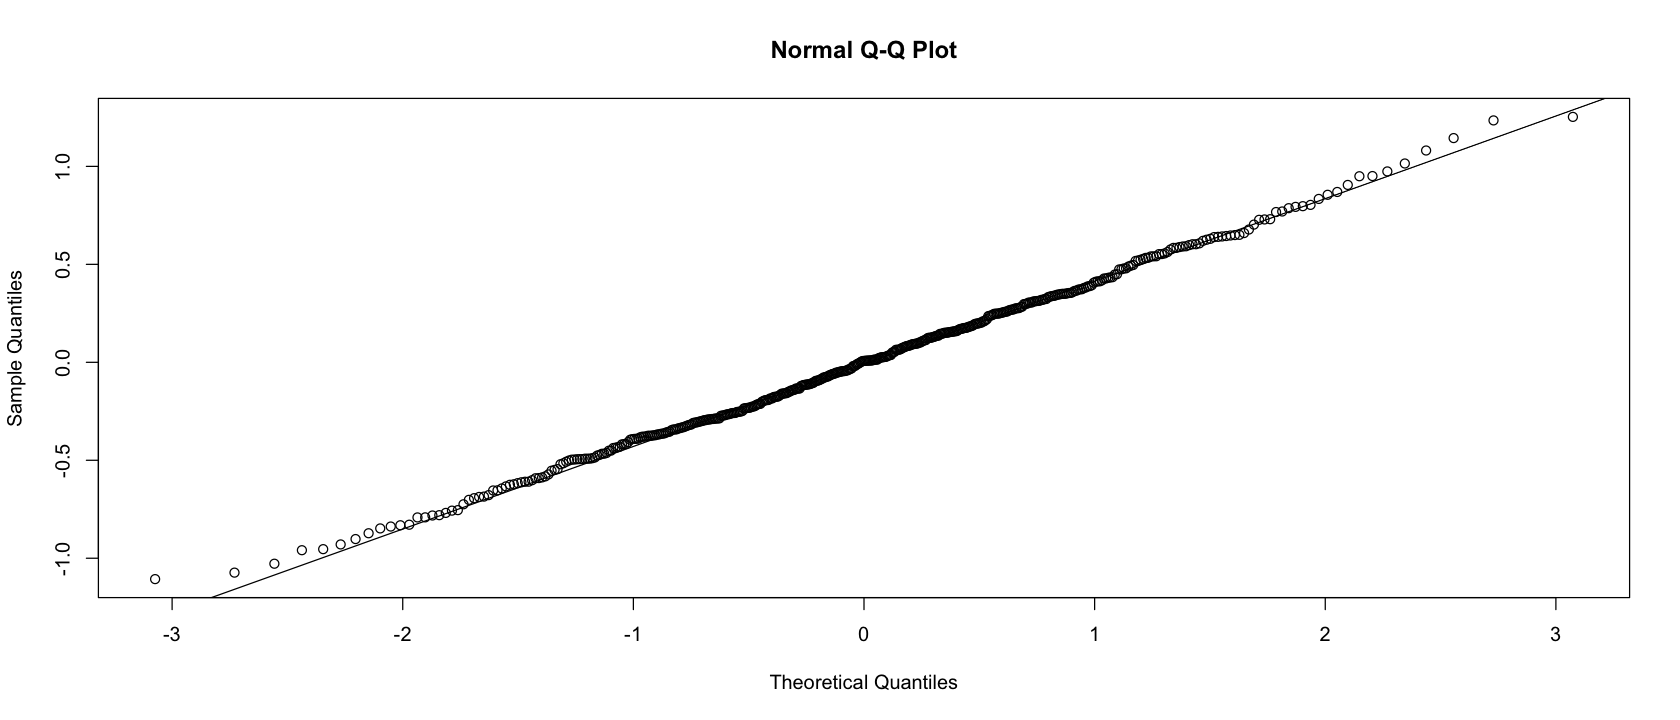

In [87]:
#diagnostics
leveneTest(log(mgN_tissue_P2)~Phase_1_treat*Phase_2_treat, Tissue_Nutrients) 
m1.e <- residuals(m1)
qqnorm(m1.e)
qqline(m1.e)

### 4.2 Mg Carbon Analysis

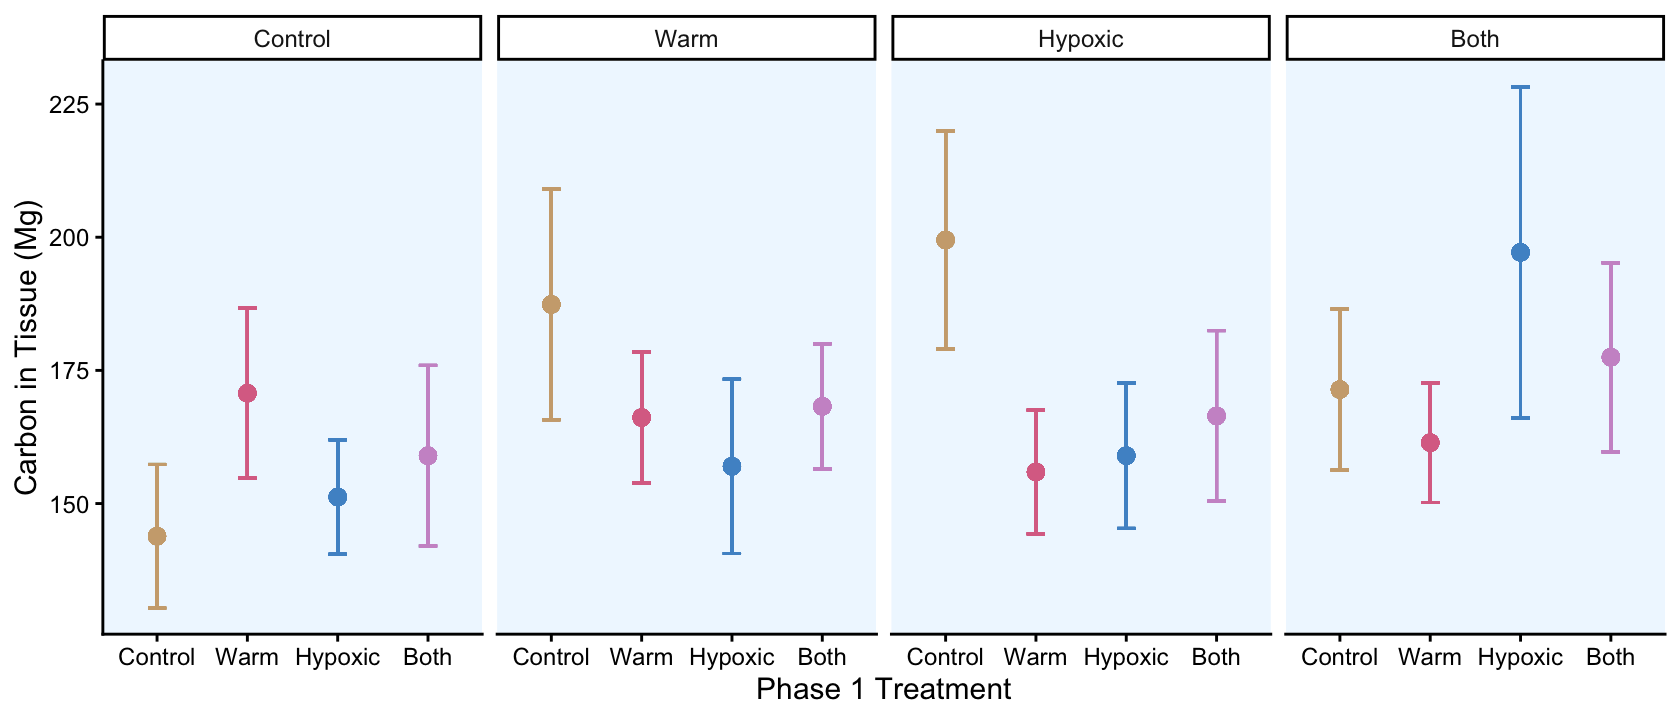

In [88]:
#format for jupyter
options(repr.plot.width = 14, repr.plot.height = 6)

#tissue nitrogen
summary_stats_t <- Tissue_Nutrients %>%
  group_by(Phase_1_treat, Phase_2_treat) %>%
  mutate(
    mean_growth = mean(mgC_tissue_P2, na.rm = TRUE),
    se_growth = std.error(mgC_tissue_P2, na.rm = TRUE))

#reorder Phase_1_treat and Phase_2_treat
summary_stats_t$Phase_1_treat <- factor(summary_stats_t$Phase_1_treat, 
                                        levels = c("Cont", "Warm","Hyp", "Both"))
summary_stats_t$Phase_2_treat <- factor(summary_stats_t$Phase_2_treat, 
                                        levels = c("Cont", "Warm","Hyp", "Both"))

#plot with mean and SD, TISSUE
ggplot(summary_stats_t, aes(x = Phase_1_treat, y = mean_growth, color = Phase_1_treat)) +
  geom_point(size = 4, position = position_dodge(0.9)) + # Plot means as points
  geom_errorbar(aes(ymin = mean_growth - se_growth, ymax = mean_growth + se_growth), 
                width = 0.2, position = position_dodge(0.9)) + # Error bars for SD
  theme_classic(base_size = 18) +
  guides(color = "none") + # Remove legend for color
  facet_wrap(vars(Phase_2_treat), 
             labeller = as_labeller(c("Hyp" = "Hypoxic", "Cont" = "Control", "Warm" = "Warm", "Both" = "Both")), 
             scales = "fixed", nrow = 1) + # Facet by Phase_2_treat
  scale_color_manual(values = c("Hyp" = "steelblue3", "Warm" = "palevioletred", "Cont" = "burlywood3", "Both" = "plum3")) +
  labs(x = "Phase 1 Treatment", y = "Carbon in Tissue (Mg)") +
  scale_x_discrete(labels = c("Hyp" = "Hypoxic", "Cont" = "Control", "Warm" = "Warm", "Both" = "Both")) +
theme(panel.background = element_rect(fill = "aliceblue")) + #fill background light blue
  theme(legend.position = "none") # Remove legend

In [89]:
##tissue carbon
m1 <- lmer(mgC_tissue_P2~ Phase_1_DO*Phase_1_temp*Phase_2.1_temp*Phase_2.1_DO+ Actual_tissue_pre_mg+
             (1|Phase_2_rep_R)+(1|Phase_1_rep_R)+
             (1|Phase_2_rep_R:Phase_1_DO)+(1|Phase_2_rep_R:Phase_1_temp)+(1|Phase_2_rep_R:Phase_1_DO:Phase_1_temp), data = Tissue_Nutrients, REML=TRUE)
aov_tab<-Anova(m1, test="F", type="III")

#remove scientific notation
aov_tab %>%
  mutate(`Pr(>F)` = round(`Pr(>F)`, 4))

boundary (singular) fit: see help('isSingular')



,F,Df,Df.res,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),2.382263e+01,1,69.62919,0.0000
Phase_1_DO,4.744993e+00,1,12.28007,0.0496
Phase_1_temp,4.653852e-01,1,10.16426,0.5104
Phase_2.1_temp,3.840647e+00,1,19.07993,0.0648
Phase_2.1_DO,6.948980e+00,1,19.08321,0.0162
Actual_tissue_pre_mg,2.288582e+03,1,385.11183,0.0000
Phase_1_DO:Phase_1_temp,2.343109e-01,1,10.18386,0.6386
Phase_1_DO:Phase_2.1_temp,5.857969e-01,1,18.90677,0.4535
Phase_1_temp:Phase_2.1_temp,2.048976e+00,1,18.91721,0.1686


In [256]:
#posthocs
options(width = 120)
emmeans(m1,specs = pairwise ~ Phase_1_temp*Phase_2.1_temp*Phase_2.1_DO, adjust = "none")

NOTE: Results may be misleading due to involvement in interactions



$emmeans
 Phase_1_temp Phase_2.1_temp Phase_2.1_DO emmean   SE   df lower.CL upper.CL
 Ambient      Ambient        Hyp             142 4.91 25.6      132      152
 Warm         Ambient        Hyp             140 4.91 25.7      130      151
 Ambient      Warm           Hyp             151 4.90 25.4      141      161
 Warm         Warm           Hyp             151 4.93 26.0      140      161
 Ambient      Ambient        Norm            157 4.89 25.2      147      167
 Warm         Ambient        Norm            156 4.92 25.9      146      166
 Ambient      Warm           Norm            161 4.89 25.1      151      171
 Warm         Warm           Norm            142 4.91 25.7      132      152

Results are averaged over the levels of: Phase_1_DO 
Degrees-of-freedom method: kenward-roger 
Confidence level used: 0.95 

$contrasts
 contrast                                   estimate   SE   df t.ratio p.value
 Ambient Ambient Hyp - Warm Ambient Hyp        1.565 3.54 19.0   0.442  0.6634
 Am

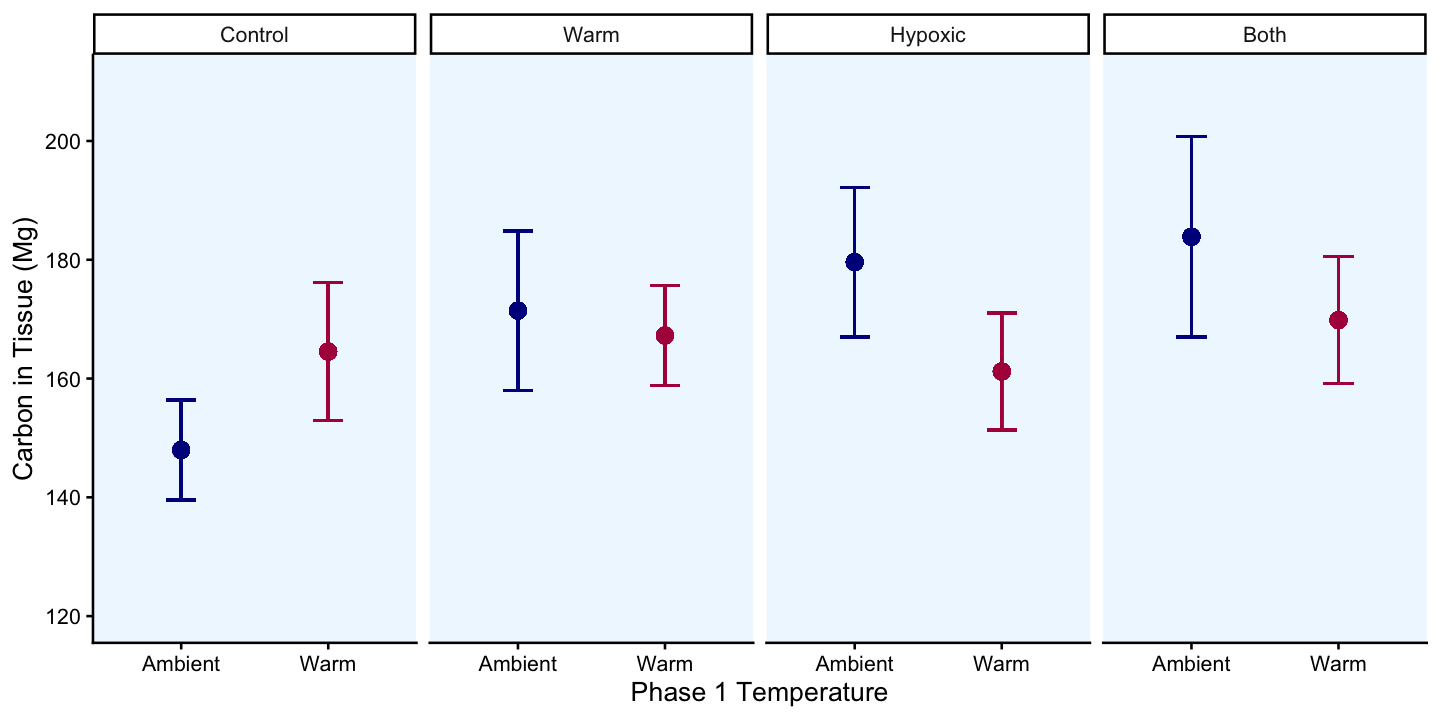

In [95]:
#format display for jupyter
options(repr.plot.width = 12, repr.plot.height = 6)

# plot Phase_1_temp:Phase_2.1_temp:Phase_2.1_DO tissue
summary_stats_t <- Tissue_Nutrients%>%
  group_by(Phase_1_temp, Phase_2_treat) %>%
  mutate(
    mean_growth = mean(mgC_tissue_P2, na.rm = TRUE),
    se_growth = std.error(mgC_tissue_P2, na.rm = TRUE))

#reorder Phase_1_treat and Phase_2_treat
summary_stats_t$Phase_1_temp <- factor(summary_stats_t$Phase_1_temp, 
                                       levels = c("Ambient", "Warm"))
summary_stats_t$Phase_2_treat <- factor(summary_stats_t$Phase_2_treat, 
                                        levels = c("Cont", "Warm","Hyp",  "Both"))

#plot with mean and SD
ggplot(summary_stats_t, aes(x = Phase_1_temp, y = mean_growth, color = Phase_1_temp)) +
  geom_point(size = 4, position = position_dodge(0.9)) + # Plot means as points
  geom_errorbar(aes(ymin = mean_growth - se_growth, ymax = mean_growth + se_growth), 
                width = 0.2, position = position_dodge(0.9)) + # Error bars for SD
  theme_classic(base_size = 16) +
  guides(color = "none") + # Remove legend for color
  facet_wrap(
    vars(Phase_2_treat),
    labeller = as_labeller(c(
      "Hyp" = "Hypoxic",
      "Cont" = "Control",
      "Warm" = "Warm",
      "Both" = "Both")), scales = "fixed", nrow = 1) +
  scale_color_manual(values = c("Warm" = "#B00149", "Ambient" = "darkblue")) +
  labs(x = "Phase 1 Temperature", y = "Carbon in Tissue (Mg)") +
  scale_x_discrete(labels = c("Hyp" = "Hypoxic", "Cont" = "Control", "Warm" = "Warm", "Both" = "Both")) +
theme(panel.background = element_rect(fill = "aliceblue")) + #fill background light blue
ylim(120, 210)+
  theme(legend.position = "none") # Remove legend

In [ ]:
 Ambient Ambient Hyp - Ambient Ambient Norm  -14.574 6.93 25.5  -2.104  0.0454
    amb hyp - amb cont
 Ambient Ambient Hyp - Ambient Warm Norm     -18.668 6.92 25.5  -2.696  0.0122
    amb hyp - amb warm
 Warm Ambient Hyp - Ambient Ambient Norm     -16.139 6.93 25.4  -2.329  0.0281
    warm hyp - amb cont
 Warm Ambient Hyp - Warm Ambient Norm        -15.455 6.96 26.0  -2.222  0.0352
    warm hyp - warm cont
 Warm Ambient Hyp - Ambient Warm Norm        -20.233 6.93 25.4  -2.920  0.0072
    warm hyp - amb warm
 Ambient Ambient Norm - Warm Warm Norm        14.269 6.93 25.4   2.059  0.0498
    amb cont - warm warm
 Ambient Warm Norm - Warm Warm Norm           18.363 3.51 18.4   5.233 <0.0001
    amb warm - warm warm

In [97]:
#posthocs
options(width = 120)
emmeans(m1,specs = pairwise ~ Phase_1_DO, adjust = "none")

NOTE: Results may be misleading due to involvement in interactions



$emmeans
 Phase_1_DO emmean   SE   df lower.CL upper.CL
 Hyp           172 3.08 22.5      166      179
 Norm          164 3.13 24.3      158      171

Results are averaged over the levels of: Phase_1_temp, Phase_2.1_temp, Phase_2.1_DO 
Degrees-of-freedom method: kenward-roger 
Confidence level used: 0.95 

$contrasts
 contrast   estimate   SE   df t.ratio p.value
 Hyp - Norm     8.01 3.68 12.3   2.178  0.0496

Results are averaged over the levels of: Phase_1_temp, Phase_2.1_temp, Phase_2.1_DO 
Degrees-of-freedom method: kenward-roger 


In [112]:
(172-164)/172

[1] 0.04651163

In [113]:
#posthocs
options(width = 120)
emmeans(m1,specs = pairwise ~ Phase_2.1_DO, adjust = "none")

NOTE: Results may be misleading due to involvement in interactions



$emmeans
 Phase_2.1_DO emmean   SE   df lower.CL upper.CL
 Hyp             175 3.49 18.4      167      182
 Norm            162 3.58 18.4      154      169

Results are averaged over the levels of: Phase_1_DO, Phase_1_temp, Phase_2.1_temp 
Degrees-of-freedom method: kenward-roger 
Confidence level used: 0.95 

$contrasts
 contrast   estimate   SE   df t.ratio p.value
 Hyp - Norm     13.2 5.01 19.1   2.636  0.0162

Results are averaged over the levels of: Phase_1_DO, Phase_1_temp, Phase_2.1_temp 
Degrees-of-freedom method: kenward-roger 


In [114]:
(175-162)/175

[1] 0.07428571

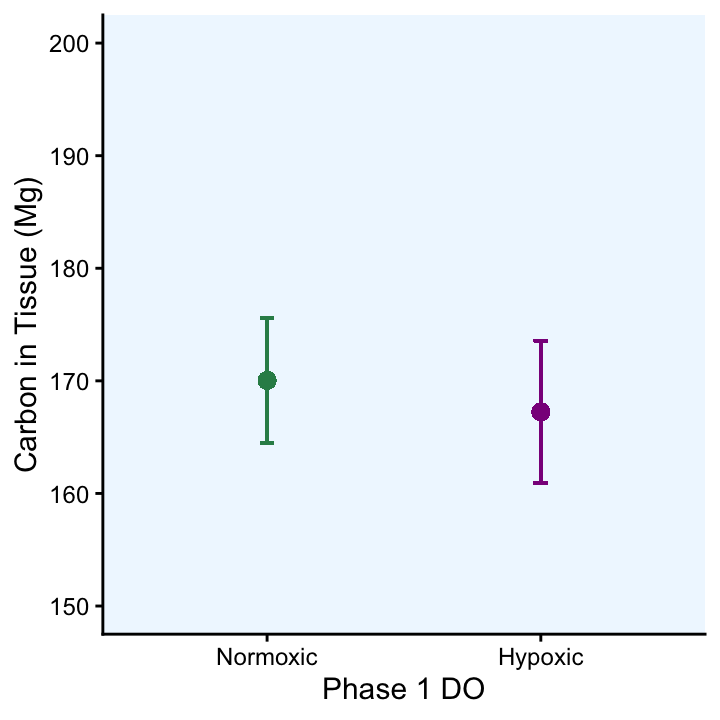

In [116]:
#format display for jupyter
options(repr.plot.width = 6, repr.plot.height = 6)

#summary stats
summary_stats <- Tissue_Nutrients %>%
  group_by(Phase_1_DO) %>%
  mutate(
    mean_cn = mean(mgC_tissue_P2, na.rm = TRUE),
    se_cn = std.error(mgC_tissue_P2, na.rm = TRUE))

#reorder
summary_stats$Phase_1_DO <- factor(summary_stats$Phase_1_DO, levels = c("Norm", "Hyp"))
#Tissue plot with mean and SD
ggplot(summary_stats, aes(x = Phase_1_DO, y = mean_cn, color = Phase_1_DO)) +
  geom_point(size = 4, position = position_dodge(0.9)) + # Plot means as points
  geom_errorbar(aes(ymin = mean_cn - se_cn, ymax = mean_cn + se_cn), 
                width = 0.05, position = position_dodge(0.9)) + # Error bars for SD
  theme_classic(base_size = 18) +
  theme(panel.background = element_rect(fill = "aliceblue")) + #fill background light blue
  guides(color = "none") + # Remove legend for color
  scale_color_manual(values = c("Hyp" = "darkmagenta", "Norm" = "seagreen")) +
  labs(x = "Phase 1 DO", y = "Carbon in Tissue (Mg)") +
  scale_x_discrete(labels = c("Hyp" = "Hypoxic", "Norm" = "Normoxic")) +
  ylim(150,200)+
  theme(legend.position = "none") # Remove legend

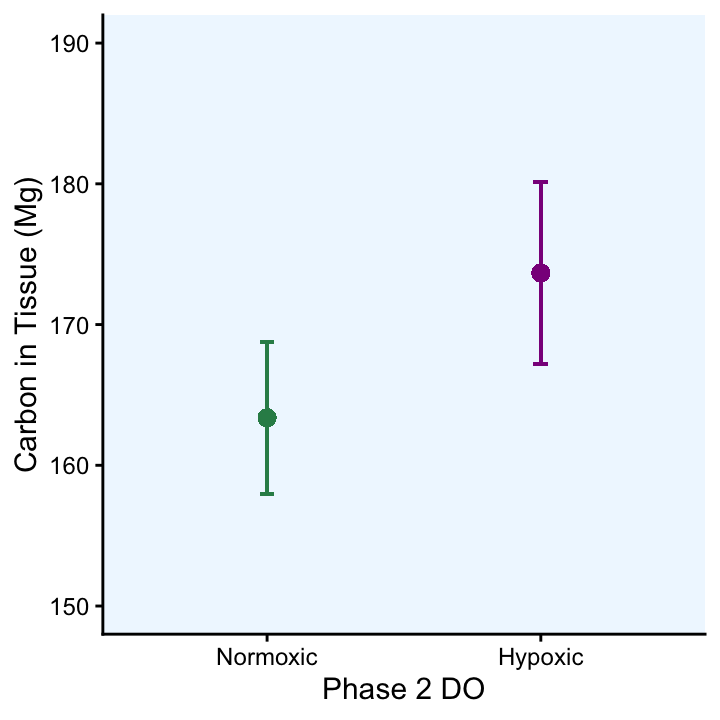

In [115]:
#format display for jupyter
options(repr.plot.width = 6, repr.plot.height = 6)

#summary stats
summary_stats <- Tissue_Nutrients %>%
  group_by(Phase_2.1_DO) %>%
  mutate(
    mean_cn = mean(mgC_tissue_P2, na.rm = TRUE),
    se_cn = std.error(mgC_tissue_P2, na.rm = TRUE))

#reorder
summary_stats$Phase_2.1_DO <- factor(summary_stats$Phase_2.1_DO, levels = c("Norm", "Hyp"))
#Tissue plot with mean and SD
ggplot(summary_stats, aes(x = Phase_2.1_DO, y = mean_cn, color = Phase_2.1_DO)) +
  geom_point(size = 4, position = position_dodge(0.9)) + # Plot means as points
  geom_errorbar(aes(ymin = mean_cn - se_cn, ymax = mean_cn + se_cn), 
                width = 0.05, position = position_dodge(0.9)) + # Error bars for SD
  theme_classic(base_size = 18) +
  theme(panel.background = element_rect(fill = "aliceblue")) + #fill background light blue
  guides(color = "none") + # Remove legend for color
  scale_color_manual(values = c("Hyp" = "darkmagenta", "Norm" = "seagreen")) +
  labs(x = "Phase 2 DO", y = "Carbon in Tissue (Mg)") +
  scale_x_discrete(labels = c("Hyp" = "Hypoxic", "Norm" = "Normoxic")) +
  ylim(150,190)+
  theme(legend.position = "none") # Remove legend

,Df,F value,Pr(>F)
,<int>,<dbl>,<dbl>
group,15,1.342198,0.1726835
,457,NA,NA


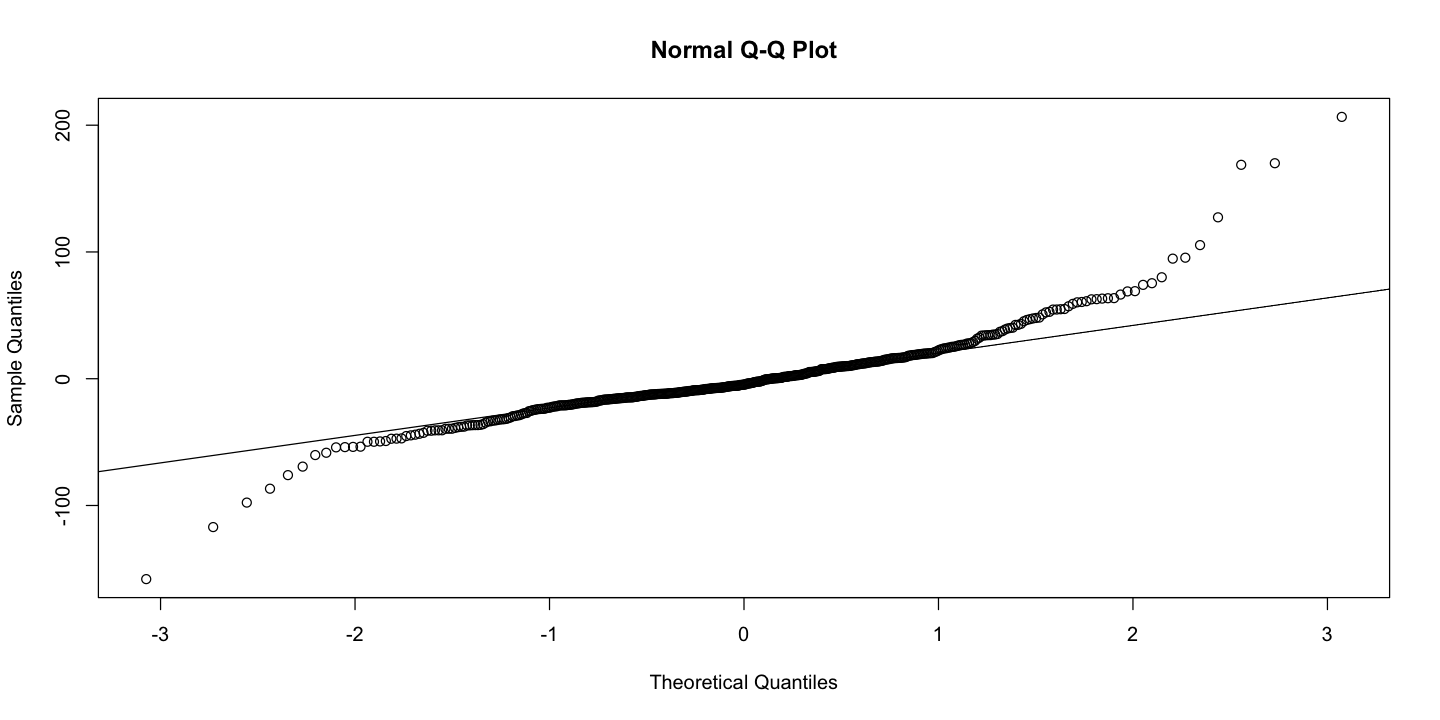

In [96]:
#diagnostics
leveneTest(mgC_tissue_P2~Phase_1_treat*Phase_2_treat, Tissue_Nutrients) 
m1.e <- residuals(m1) 
qqnorm(m1.e)
qqline(m1.e)

# Shell

## 1. % Nitrogen in Shell

In [117]:
#filter data
Shell_Nitrogen <- nutrient_df%>%
filter(Tissue_type == "S")%>%
filter(is.na(N_Exclude))

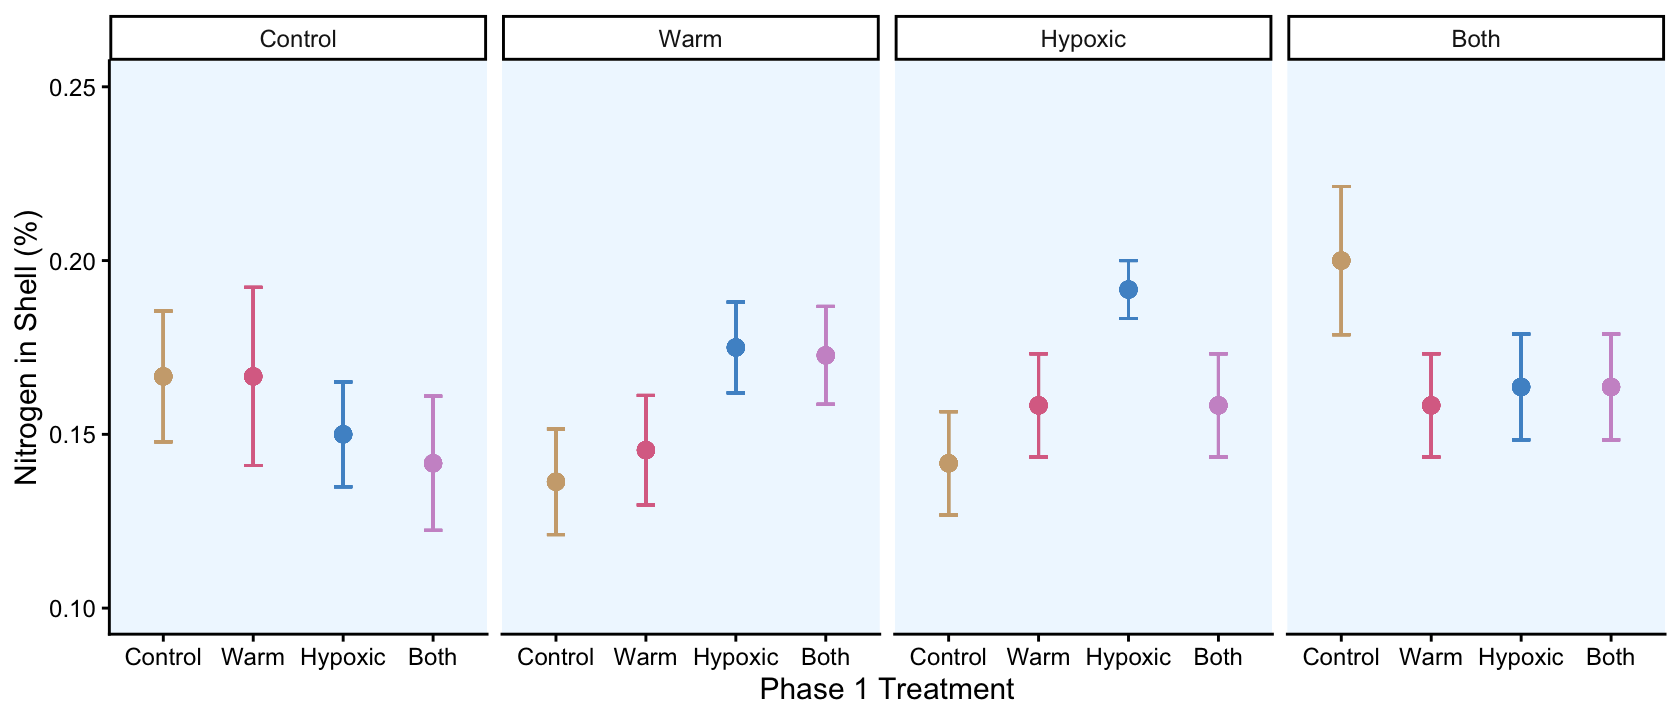

In [123]:
#format for jupyter
options(repr.plot.width = 14, repr.plot.height = 6)

#tissue nitrogen
summary_stats_t <- Shell_Nitrogen %>%
  group_by(Phase_1_treat, Phase_2_treat) %>%
  mutate(
    mean_growth = mean(wt_percent_n, na.rm = TRUE),
    se_growth = std.error(wt_percent_n, na.rm = TRUE))

#reorder Phase_1_treat and Phase_2_treat
summary_stats_t$Phase_1_treat <- factor(summary_stats_t$Phase_1_treat, 
                                        levels = c("Cont", "Warm","Hyp", "Both"))
summary_stats_t$Phase_2_treat <- factor(summary_stats_t$Phase_2_treat, 
                                        levels = c("Cont", "Warm","Hyp", "Both"))

#plot with mean and SD, TISSUE
ggplot(summary_stats_t, aes(x = Phase_1_treat, y = mean_growth, color = Phase_1_treat)) +
  geom_point(size = 4, position = position_dodge(0.9)) + # Plot means as points
  geom_errorbar(aes(ymin = mean_growth - se_growth, ymax = mean_growth + se_growth), 
                width = 0.2, position = position_dodge(0.9)) + # Error bars for SD
  theme_classic(base_size = 18) +
  guides(color = "none") + # Remove legend for color
  facet_wrap(vars(Phase_2_treat), 
             labeller = as_labeller(c("Hyp" = "Hypoxic", "Cont" = "Control", "Warm" = "Warm", "Both" = "Both")), 
             scales = "fixed", nrow = 1) + # Facet by Phase_2_treat
  scale_color_manual(values = c("Hyp" = "steelblue3", "Warm" = "palevioletred", "Cont" = "burlywood3", "Both" = "plum3")) +
  labs(x = "Phase 1 Treatment", y = "Nitrogen in Shell (%)") +
  scale_x_discrete(labels = c("Hyp" = "Hypoxic", "Cont" = "Control", "Warm" = "Warm", "Both" = "Both")) +
theme(panel.background = element_rect(fill = "aliceblue")) + #fill background light blue
  ylim(0.1, 0.25)+
  theme(legend.position = "none") # Remove legend

In [124]:
##shell nitrogen
m1 <- lmer(wt_percent_n~ Phase_1_DO*Phase_1_temp*Phase_2.1_temp*Phase_2.1_DO+
             (1|Phase_2_rep_R)+(1|Phase_1_rep_R)+
             (1|Phase_2_rep_R:Phase_1_DO)+(1|Phase_2_rep_R:Phase_1_temp)+(1|Phase_2_rep_R:Phase_1_DO:Phase_1_temp), data = Shell_Nitrogen, REML=TRUE)
aov_tab<-Anova(m1, test="F", type="III")

#remove scientific notation
aov_tab %>%
  mutate(`Pr(>F)` = round(`Pr(>F)`, 4))

boundary (singular) fit: see help('isSingular')



,F,Df,Df.res,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),1.452624e+03,1,10.229112,0.0000
Phase_1_DO,4.314664e-01,1,9.793364,0.5264
Phase_1_temp,7.978597e-01,1,9.795704,0.3931
Phase_2.1_temp,3.442463e-01,1,18.678531,0.5644
Phase_2.1_DO,1.415425e+00,1,18.734460,0.2490
Phase_1_DO:Phase_1_temp,1.801189e-01,1,9.794467,0.6804
Phase_1_DO:Phase_2.1_temp,1.543166e-01,1,18.646554,0.6989
Phase_1_temp:Phase_2.1_temp,2.419900e-02,1,18.648084,0.8781
Phase_1_DO:Phase_2.1_DO,8.061719e-03,1,18.707380,0.9294


In [135]:
#posthocs
options(width = 120)
emmeans(m1,specs = pairwise ~ Phase_1_DO*Phase_2.1_temp*Phase_2.1_DO, adjust = "none")

NOTE: Results may be misleading due to involvement in interactions



$emmeans
 Phase_1_DO Phase_2.1_temp Phase_2.1_DO emmean     SE   df lower.CL upper.CL
 Hyp        Ambient        Hyp           0.175 0.0117 36.4    0.151    0.199
 Norm       Ambient        Hyp           0.150 0.0117 36.4    0.126    0.174
 Hyp        Warm           Hyp           0.164 0.0122 41.8    0.139    0.188
 Norm       Warm           Hyp           0.179 0.0117 36.1    0.155    0.203
 Hyp        Ambient        Norm          0.146 0.0118 28.3    0.122    0.170
 Norm       Ambient        Norm          0.167 0.0118 24.8    0.142    0.191
 Hyp        Warm           Norm          0.174 0.0119 39.3    0.150    0.198
 Norm       Warm           Norm          0.141 0.0123 41.4    0.116    0.166

Results are averaged over the levels of: Phase_1_temp 
Degrees-of-freedom method: kenward-roger 
Confidence level used: 0.95 

$contrasts
 contrast                             estimate     SE   df t.ratio p.value
 Hyp Ambient Hyp - Norm Ambient Hyp    0.02500 0.0163 18.7   1.533  0.1421
 Hyp Ambi

,Df,F value,Pr(>F)
,<int>,<dbl>,<dbl>
group,15,0.7509331,0.7297672
,171,NA,NA


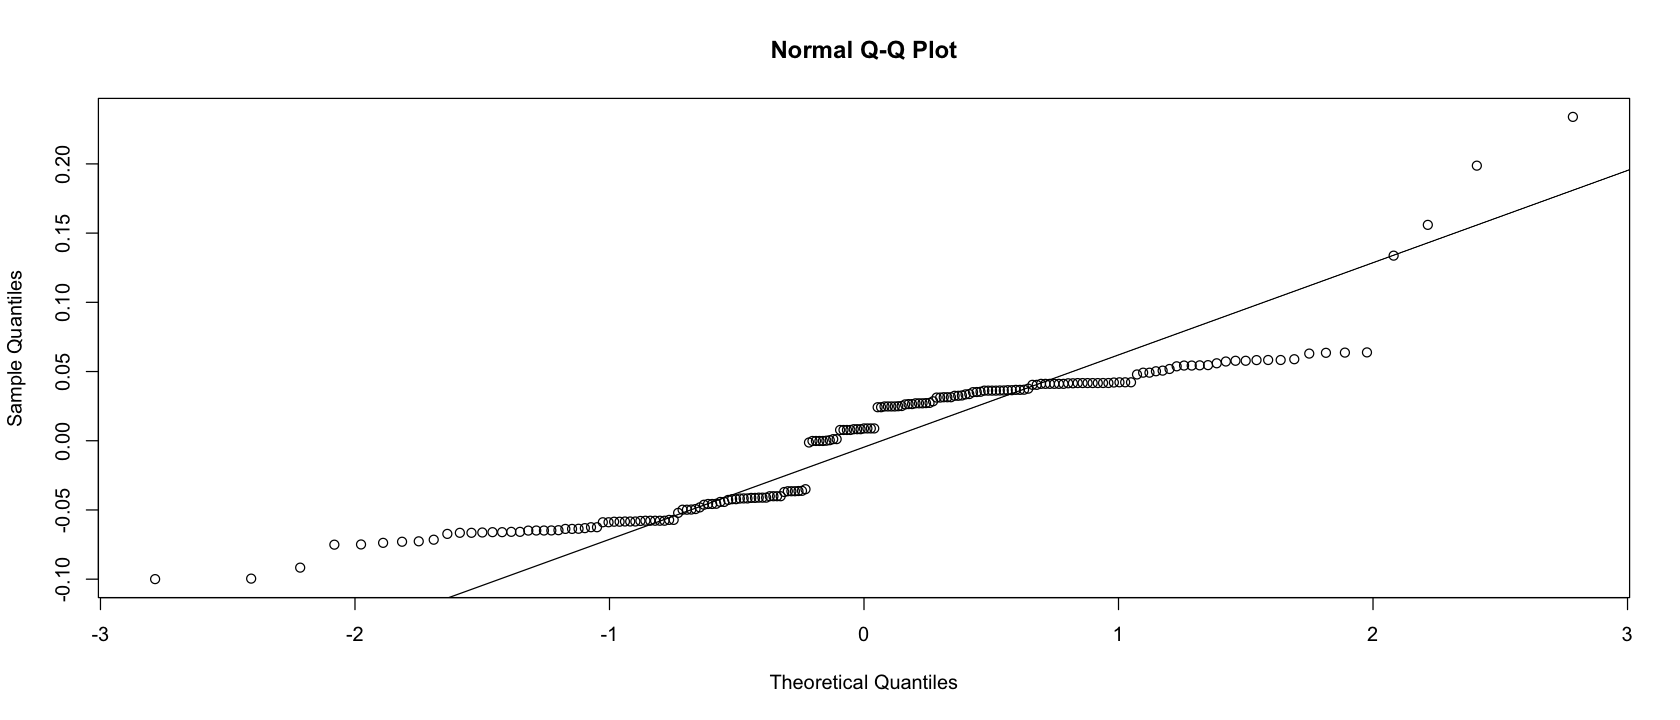

In [125]:
#diagnostics
leveneTest(wt_percent_n~Phase_1_treat*Phase_2_treat, Shell_Nitrogen) 
m1.e <- residuals(m1) 
qqnorm(m1.e)
qqline(m1.e)

## 2. % Carbon in Shell

In [126]:
#filter data
Shell_Carbon <- nutrient_df%>%
filter(Tissue_type == "S")#%>%
#filter(is.na(c_exclude))

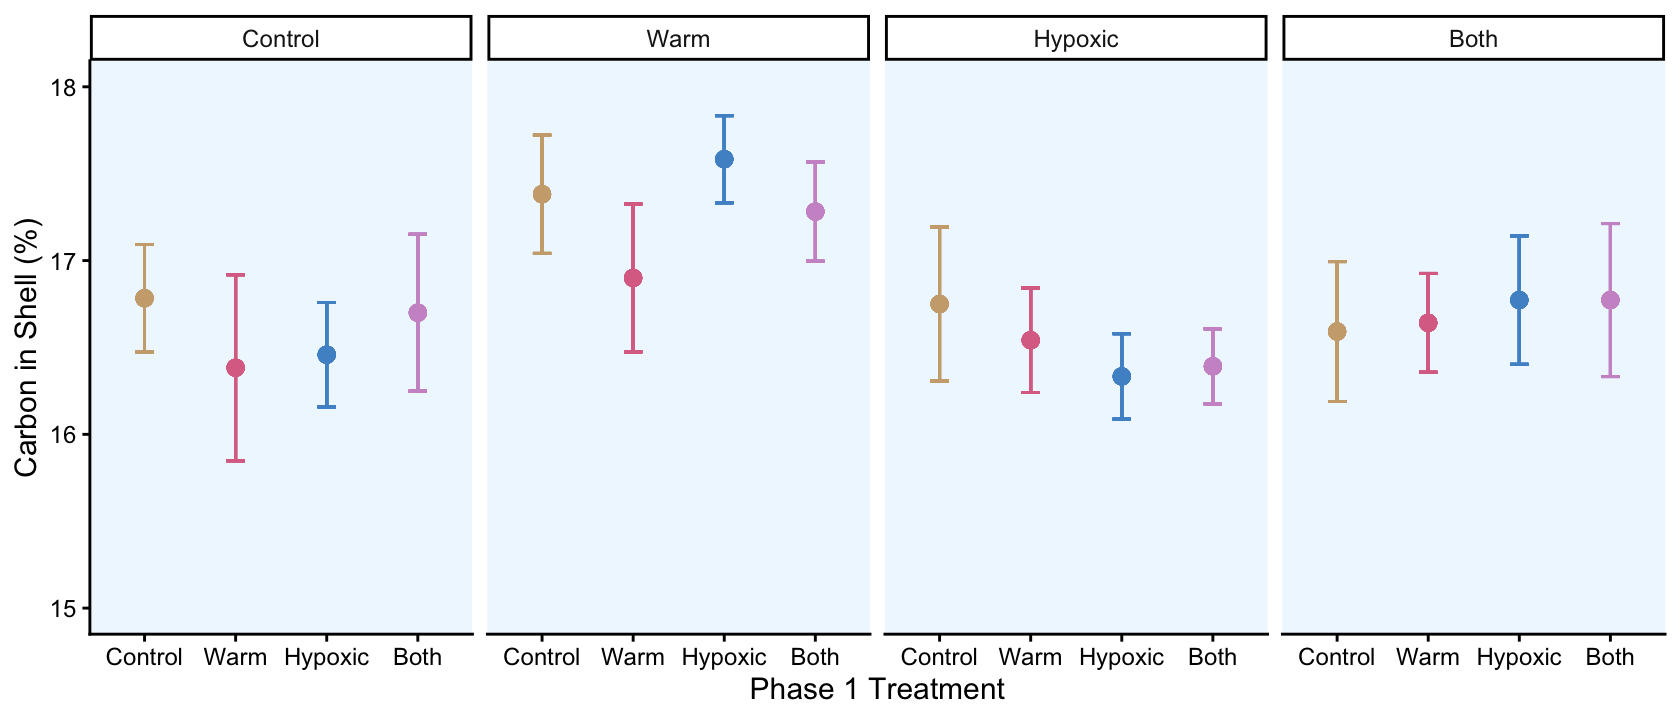

In [128]:
#tissue carbon
summary_stats_t <- Shell_Carbon %>%
  group_by(Phase_1_treat, Phase_2_treat) %>%
  mutate(
    mean_growth = mean(wt_percent_c, na.rm = TRUE),
    se_growth = std.error(wt_percent_c, na.rm = TRUE))

#reorder Phase_1_treat and Phase_2_treat
summary_stats_t$Phase_1_treat <- factor(summary_stats_t$Phase_1_treat, 
                                        levels = c("Cont", "Warm","Hyp", "Both"))
summary_stats_t$Phase_2_treat <- factor(summary_stats_t$Phase_2_treat, 
                                        levels = c("Cont", "Warm","Hyp", "Both"))

#plot with mean and SD, TISSUE
ggplot(summary_stats_t, aes(x = Phase_1_treat, y = mean_growth, color = Phase_1_treat)) +
  geom_point(size = 4, position = position_dodge(0.9)) + # Plot means as points
  geom_errorbar(aes(ymin = mean_growth - se_growth, ymax = mean_growth + se_growth), 
                width = 0.2, position = position_dodge(0.9)) + # Error bars for SD
  theme_classic(base_size = 18) +
  guides(color = "none") + # Remove legend for color
  facet_wrap(vars(Phase_2_treat), 
             labeller = as_labeller(c("Hyp" = "Hypoxic", "Cont" = "Control", "Warm" = "Warm", "Both" = "Both")), 
             scales = "fixed", nrow = 1) + # Facet by Phase_2_treat
  scale_color_manual(values = c("Hyp" = "steelblue3", "Warm" = "palevioletred", "Cont" = "burlywood3", "Both" = "plum3")) +
  labs(x = "Phase 1 Treatment", y = "Carbon in Shell (%)") +
  scale_x_discrete(labels = c("Hyp" = "Hypoxic", "Cont" = "Control", "Warm" = "Warm", "Both" = "Both")) +
theme(panel.background = element_rect(fill = "aliceblue")) + #fill background light blue
ylim(15,18)+
  theme(legend.position = "none") # Remove legend

In [129]:
##Shell carbon
m2 <- lmer(wt_percent_c~ Phase_1_DO*Phase_1_temp*Phase_2.1_temp*Phase_2.1_DO+
             (1|Phase_2_rep_R)+(1|Phase_1_rep_R)+
             (1|Phase_2_rep_R:Phase_1_DO)+(1|Phase_2_rep_R:Phase_1_temp)+(1|Phase_2_rep_R:Phase_1_DO:Phase_1_temp), data = Shell_Carbon, REML=TRUE)
aov_tab<-Anova(m2, test="F", type="III")

#remove scientific notation
aov_tab %>%
  mutate(`Pr(>F)` = round(`Pr(>F)`, 4))

boundary (singular) fit: see help('isSingular')



,F,Df,Df.res,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),1.577697e+04,1,19.76095,0.0000
Phase_1_DO,1.214818e-03,1,17.47838,0.9726
Phase_1_temp,3.388217e-01,1,16.21872,0.5685
Phase_2.1_temp,3.780803e+00,1,18.44756,0.0673
Phase_2.1_DO,2.191686e+00,1,18.62181,0.1555
Phase_1_DO:Phase_1_temp,1.617231e-01,1,16.21789,0.6928
Phase_1_DO:Phase_2.1_temp,9.608654e-01,1,18.07660,0.3399
Phase_1_temp:Phase_2.1_temp,1.036737e-01,1,17.88881,0.7512
Phase_1_DO:Phase_2.1_DO,6.421946e-02,1,18.29592,0.8028


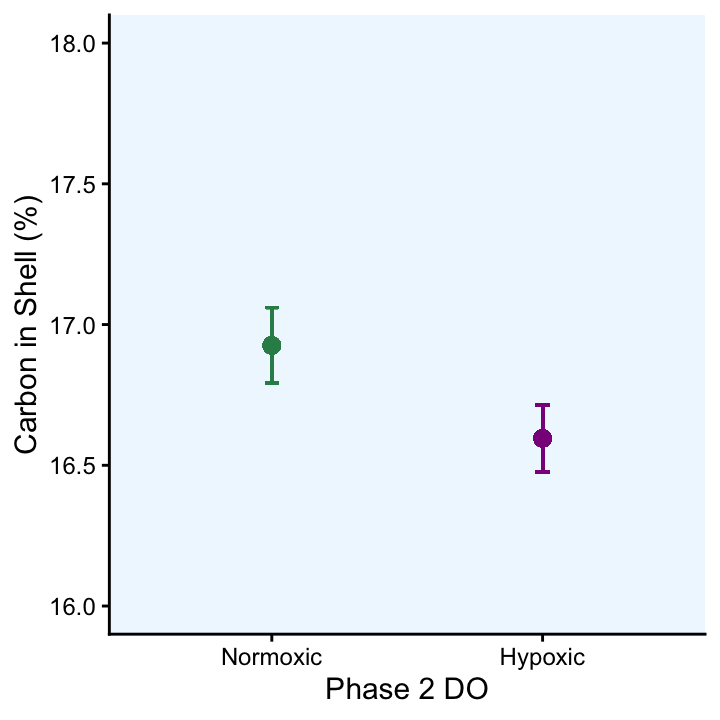

In [134]:
#format display for jupyter
options(repr.plot.width = 6, repr.plot.height = 6)

#summary stats
summary_stats <- Shell_Carbon %>%
  group_by(Phase_2.1_DO) %>%
  mutate(
    mean_cn = mean(wt_percent_c, na.rm = TRUE),
    se_cn = std.error(wt_percent_c, na.rm = TRUE))

#reorder
summary_stats$Phase_2.1_DO <- factor(summary_stats$Phase_2.1_DO, levels = c("Norm", "Hyp"))
#Tissue plot with mean and SD
ggplot(summary_stats, aes(x = Phase_2.1_DO, y = mean_cn, color = Phase_2.1_DO)) +
  geom_point(size = 4, position = position_dodge(0.9)) + # Plot means as points
  geom_errorbar(aes(ymin = mean_cn - se_cn, ymax = mean_cn + se_cn), 
                width = 0.05, position = position_dodge(0.9)) + # Error bars for SD
  theme_classic(base_size = 18) +
  theme(panel.background = element_rect(fill = "aliceblue")) + #fill background light blue
  guides(color = "none") + # Remove legend for color
  scale_color_manual(values = c("Hyp" = "darkmagenta", "Norm" = "seagreen")) +
  labs(x = "Phase 2 DO", y = "Carbon in Shell (%)") +
  scale_x_discrete(labels = c("Hyp" = "Hypoxic", "Norm" = "Normoxic")) +
  ylim(16,18)+
  theme(legend.position = "none") # Remove legend

,Df,F value,Pr(>F)
,<int>,<dbl>,<dbl>
group,15,0.7784794,0.7001369
,171,NA,NA


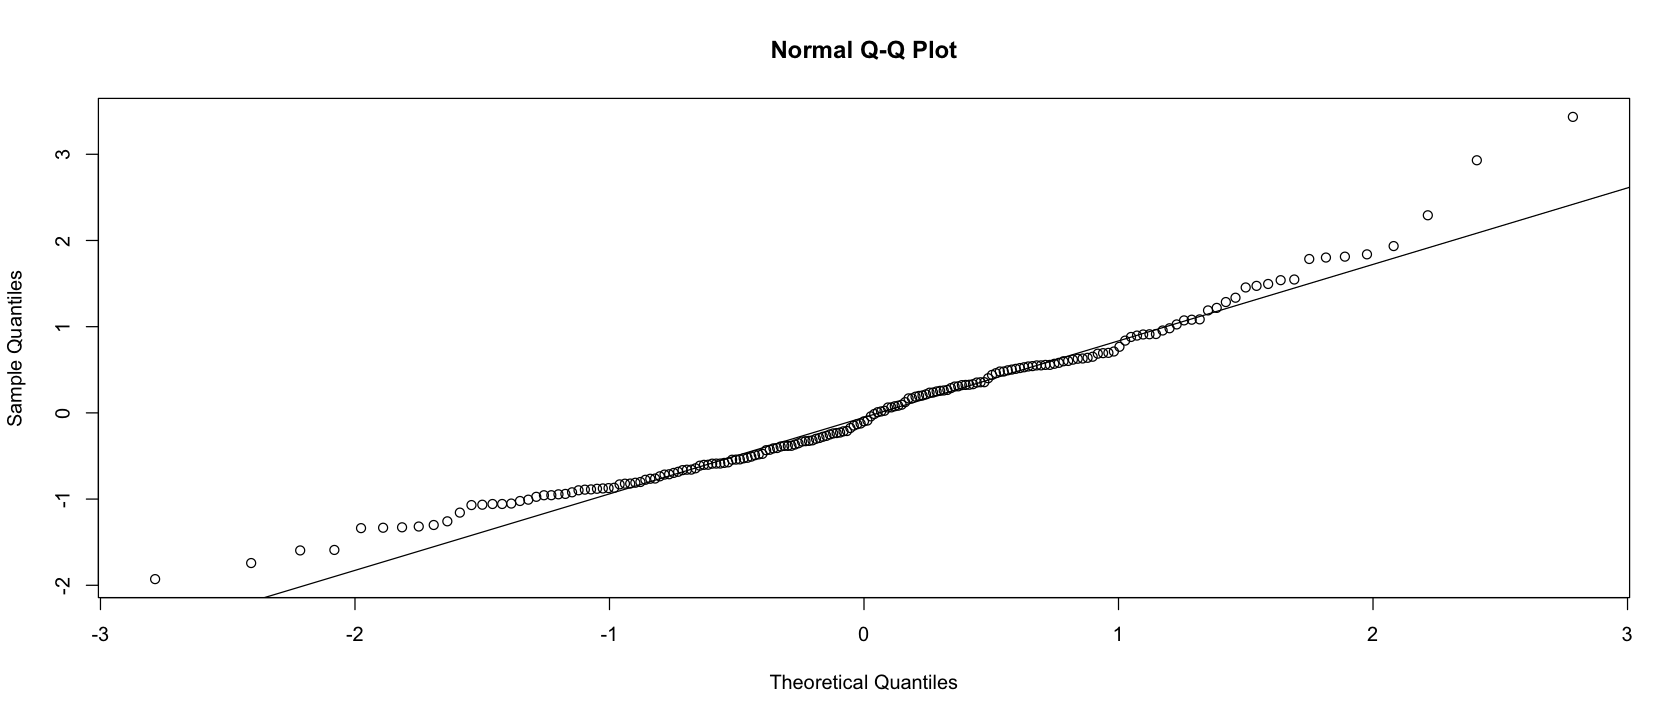

In [130]:
#diagnostics
leveneTest(wt_percent_c~Phase_1_treat*Phase_2_treat, Shell_Carbon) 
m1.e <- residuals(m2) 
qqnorm(m1.e)
qqline(m1.e)

## 3. Carbon:Nitrogen in Shell

In [273]:
#filter data
Shell_CN <- df%>%
filter(Tissue_type == "S")%>%
filter(is.na(n_exclude))%>%
filter(is.na(c_exclude))%>%
mutate(C_N = (wt_percent_c/wt_percent_n))

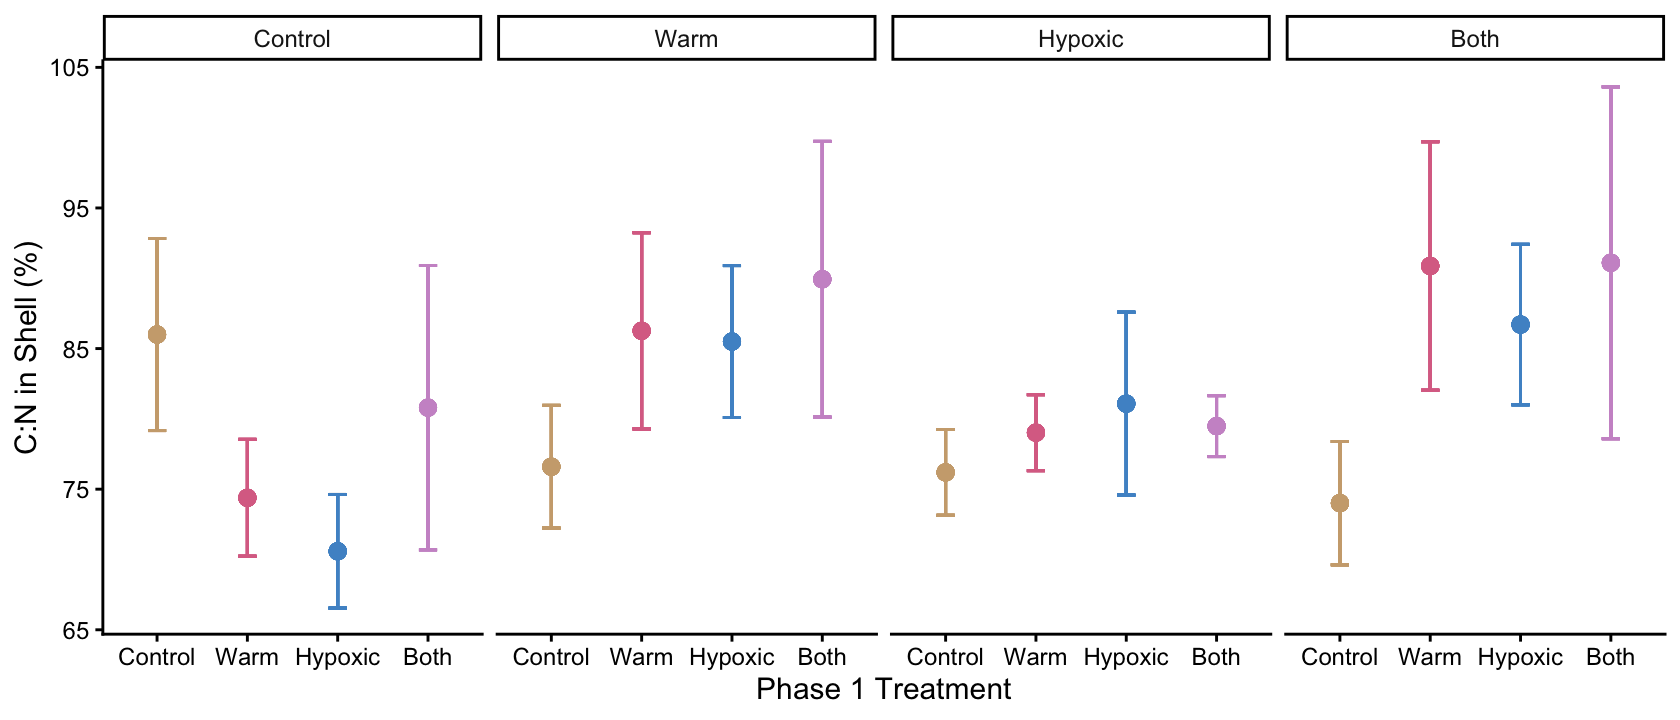

In [274]:
#tissue c:n
summary_stats_t <- Shell_CN %>%
  group_by(Phase_1_treat, Phase_2_treat) %>%
  mutate(
    mean_growth = mean(C_N, na.rm = TRUE),
    se_growth = std.error(C_N, na.rm = TRUE))

#reorder Phase_1_treat and Phase_2_treat
summary_stats_t$Phase_1_treat <- factor(summary_stats_t$Phase_1_treat, 
                                        levels = c("Cont", "Warm","Hyp", "Both"))
summary_stats_t$Phase_2_treat <- factor(summary_stats_t$Phase_2_treat, 
                                        levels = c("Cont", "Warm","Hyp", "Both"))

#plot with mean and SD, TISSUE
ggplot(summary_stats_t, aes(x = Phase_1_treat, y = mean_growth, color = Phase_1_treat)) +
  geom_point(size = 4, position = position_dodge(0.9)) + # Plot means as points
  geom_errorbar(aes(ymin = mean_growth - se_growth, ymax = mean_growth + se_growth), 
                width = 0.2, position = position_dodge(0.9)) + # Error bars for SD
  theme_classic(base_size = 18) +
  guides(color = "none") + # Remove legend for color
  facet_wrap(vars(Phase_2_treat), 
             labeller = as_labeller(c("Hyp" = "Hypoxic", "Cont" = "Control", "Warm" = "Warm", "Both" = "Both")), 
             scales = "fixed", nrow = 1) + # Facet by Phase_2_treat
  scale_color_manual(values = c("Hyp" = "steelblue3", "Warm" = "palevioletred", "Cont" = "burlywood3", "Both" = "plum3")) +
  labs(x = "Phase 1 Treatment", y = "C:N in Shell (%)") +
  scale_x_discrete(labels = c("Hyp" = "Hypoxic", "Cont" = "Control", "Warm" = "Warm", "Both" = "Both")) +
  theme(legend.position = "none") # Remove legend

In [127]:
##shell carbon:nitrogen
m3 <- lmer((wt_percent_c/wt_percent_n)~ Phase_1_DO*Phase_1_temp*Phase_2.1_temp*Phase_2.1_DO+
             (1|Phase_2_rep_R)+(1|Phase_1_rep_R)+
             (1|Phase_2_rep_R:Phase_1_DO)+(1|Phase_2_rep_R:Phase_1_temp)+(1|Phase_2_rep_R:Phase_1_DO:Phase_1_temp), data = Shell_CN, REML=TRUE)
aov_tab<-Anova(m3, test="F", type="III")

#remove scientific notation
aov_tab %>%
  mutate(`Pr(>F)` = round(`Pr(>F)`, 4))

boundary (singular) fit: see help('isSingular')



,F,Df,Df.res,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),1.574742e+03,1,14.68914,0.0000
Phase_1_DO,3.676224e-01,1,10.52370,0.5572
Phase_1_temp,1.231866e+00,1,10.52333,0.2918
Phase_2.1_temp,3.421284e+00,1,19.77954,0.0794
Phase_2.1_DO,2.086412e-01,1,19.77954,0.6528
Phase_1_DO:Phase_1_temp,5.242249e-02,1,10.52370,0.8233
Phase_1_DO:Phase_2.1_temp,1.886709e+00,1,19.58366,0.1851
Phase_1_temp:Phase_2.1_temp,2.618342e+00,1,19.58384,0.1216
Phase_1_DO:Phase_2.1_DO,6.598977e-01,1,19.58366,0.4264


,Df,F value,Pr(>F)
,<int>,<dbl>,<dbl>
group,15,0.9179332,0.5453829
,174,NA,NA


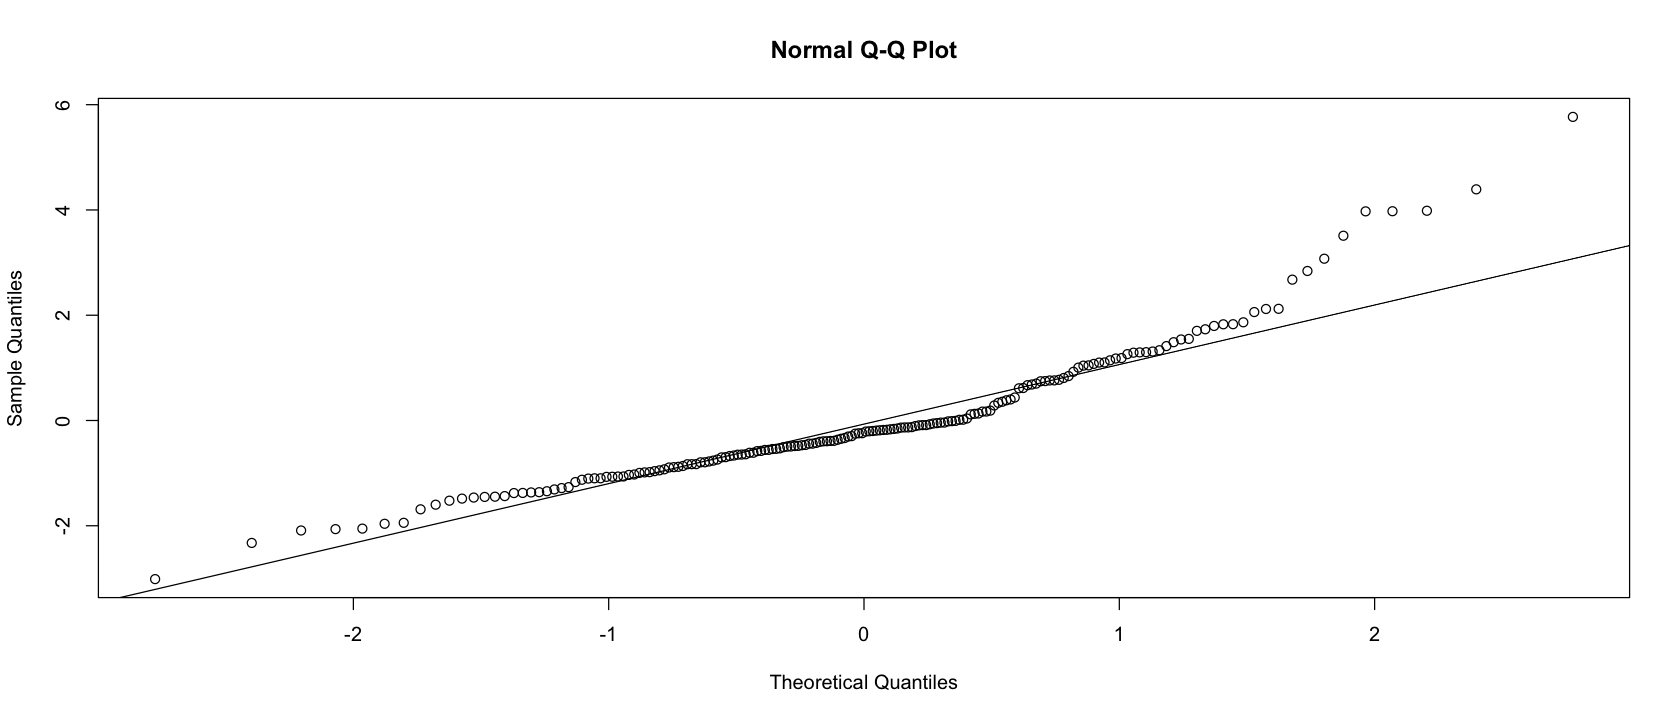

In [275]:
#diagnostics
leveneTest(C_N~Phase_1_treat*Phase_2_treat, Shell_CN) 
m1.e <- residuals(m3) 
qqnorm(m1.e)
qqline(m1.e)

## 4. Mg Carbon and Nitrogen in Shell

In [276]:
#calculate % N averages Tissue

summary_stats_s <- Shell_CN %>%
  group_by(Phase_1_treat, Phase_2_treat) %>%
  summarize(
    mean_N = mean(wt_percent_n, na.rm = TRUE),
    mean_C = mean(wt_percent_c, na.rm = TRUE))

print(summary_stats_s)

`summarise()` has regrouped the output.
ℹ Summaries were computed grouped by Phase_1_treat and Phase_2_treat.
ℹ Output is grouped by Phase_1_treat.
ℹ Use `summarise(.groups = "drop_last")` to silence this message.
ℹ Use `summarise(.by = c(Phase_1_treat, Phase_2_treat))` for per-operation
  grouping (`?dplyr::dplyr_by`) instead.


# A tibble: 16 × 4
# Groups:   Phase_1_treat [4]
   Phase_1_treat Phase_2_treat mean_N mean_C
   <chr>         <chr>          <dbl>  <dbl>
 1 Both          Both           0.217   16.8
 2 Both          Cont           0.22    16.2
 3 Both          Hyp            0.208   16.4
 4 Both          Warm           0.2     16.3
 5 Cont          Both           0.233   16.4
 6 Cont          Cont           0.2     16.4
 7 Cont          Hyp            0.217   16.1
 8 Cont          Warm           0.225   16.4
 9 Hyp           Both           0.192   16.1
10 Hyp           Cont           0.242   16.4
11 Hyp           Hyp            0.217   16.5
12 Hyp           Warm           0.192   15.9
13 Warm          Both           0.192   16.6
14 Warm          Cont           0.242   16.9
15 Warm          Hyp            0.208   16.2
16 Warm          Warm           0.2     16.4


In [156]:
Shell_Nutrients <- weight_df %>%
  filter(Exclude_all != "Y" | is.na(Exclude_all)) %>%
  left_join(
    summary_stats_s,
    by = c("Phase_1_treat", "Phase_2_treat")) %>%
  mutate(mgN_shell_P2 = (Actual_shell_post_mg * mean_N) / 100)%>%
  mutate(mgC_shell_P2 = (Actual_shell_post_mg * mean_C) / 100)

View(Shell_Nutrients)

Sample_Name,Order_pre,Date_MMDDYYYY_pre,Year,Phase_1_treat,Phase_1_rep,Phase_2_treat,Phase_2_rep,Tag_color,Tag_num,⋯,Phase_1_rep_R,Phase_2_rep_R,Ratio_tissue_shell_pre_mg,Phase1_Phase2_rep,Exclude_all,Exclude_pre_analysis,mean_N,mean_C,mgN_shell_P2,mgC_shell_P2
<chr>,<dbl>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,⋯,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
2024_Both01_Both01_O1,3,7/23/24,2024,Both,01,Both,01,O,1,⋯,Both01,Both01,0.9025393,Both01_Both01,NA,NA,0.2166667,16.89167,1.1734008,91.48013
2024_Both01_Both01_O2,7,7/23/24,2024,Both,01,Both,01,O,2,⋯,Both01,Both01,0.6425681,Both01_Both01,NA,NA,0.2166667,16.89167,1.3288115,103.59619
2024_Both01_Both02_O13,50,7/23/24,2024,Both,01,Both,02,O,13,⋯,Both01,Both02,0.8083796,Both01_Both02,NA,NA,0.2166667,16.89167,1.5754788,122.82675
2024_Both01_Both02_O14,55,7/23/24,2024,Both,01,Both,02,O,14,⋯,Both01,Both02,0.5888140,Both01_Both02,NA,NA,0.2166667,16.89167,1.4200681,110.71070
2024_Both01_Both03_O25,98,7/24/24,2024,Both,01,Both,03,O,25,⋯,Both01,Both03,0.7725658,Both01_Both03,NA,NA,0.2166667,16.89167,0.4196760,32.71859
2024_Both01_Both03_O26,103,7/24/24,2024,Both,01,Both,03,O,26,⋯,Both01,Both03,0.5599379,Both01_Both03,NA,NA,0.2166667,16.89167,0.9977490,77.78604
2024_Both01_Both04_O37,214,7/24/24,2024,Both,01,Both,04,O,37,⋯,Both01,Both04,0.7191106,Both01_Both04,NA,NA,0.2166667,16.89167,2.2815169,177.87057
2024_Both01_Both04_O38,111,7/24/24,2024,Both,01,Both,04,O,38,⋯,Both01,Both04,0.5380885,Both01_Both04,NA,NA,0.2166667,16.89167,0.3963472,30.89984
2024_Both01_Both05_O49,260,7/25/24,2024,Both,01,Both,05,O,49,⋯,Both01,Both05,0.5206603,Both01_Both05,NA,NA,0.2166667,16.89167,1.3401328,104.47882


### 4.1 Mg Nitrogen Analysis

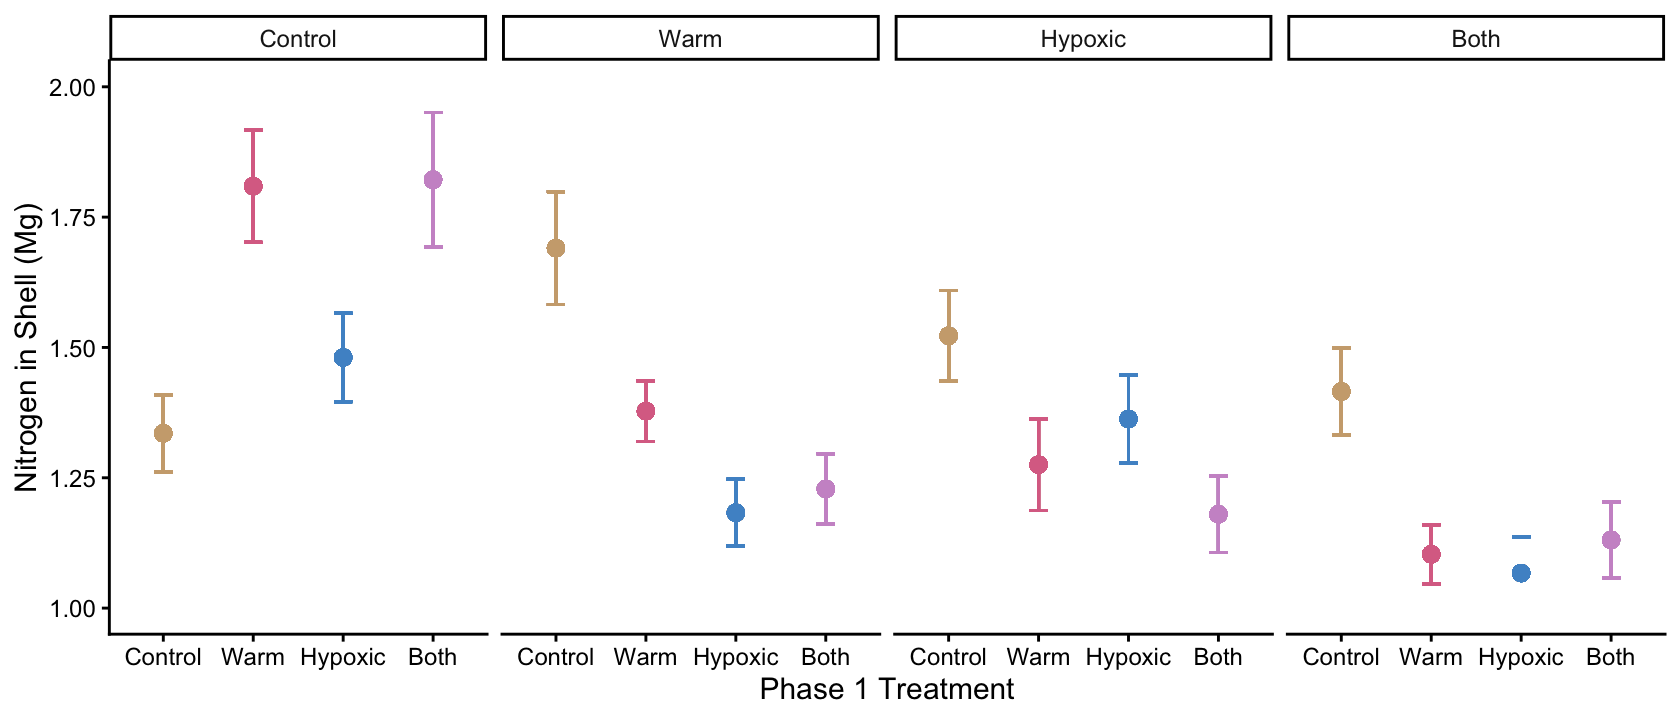

In [160]:
#format for jupyter
options(repr.plot.width = 14, repr.plot.height = 6)

#tissue nitrogen
summary_stats_t <- Shell_Nutrients %>%
  group_by(Phase_1_treat, Phase_2_treat) %>%
  mutate(
    mean_growth = mean(mgN_shell_P2, na.rm = TRUE),
    se_growth = std.error(mgN_shell_P2, na.rm = TRUE))

#reorder Phase_1_treat and Phase_2_treat
summary_stats_t$Phase_1_treat <- factor(summary_stats_t$Phase_1_treat, 
                                        levels = c("Cont", "Warm","Hyp", "Both"))
summary_stats_t$Phase_2_treat <- factor(summary_stats_t$Phase_2_treat, 
                                        levels = c("Cont", "Warm","Hyp", "Both"))

#plot with mean and SD, TISSUE
ggplot(summary_stats_t, aes(x = Phase_1_treat, y = mean_growth, color = Phase_1_treat)) +
  geom_point(size = 4, position = position_dodge(0.9)) + # Plot means as points
  geom_errorbar(aes(ymin = mean_growth - se_growth, ymax = mean_growth + se_growth), 
                width = 0.2, position = position_dodge(0.9)) + # Error bars for SD
  theme_classic(base_size = 18) +
  guides(color = "none") + # Remove legend for color
  facet_wrap(vars(Phase_2_treat), 
             labeller = as_labeller(c("Hyp" = "Hypoxic", "Cont" = "Control", "Warm" = "Warm", "Both" = "Both")), 
             scales = "fixed", nrow = 1) + # Facet by Phase_2_treat
  scale_color_manual(values = c("Hyp" = "steelblue3", "Warm" = "palevioletred", "Cont" = "burlywood3", "Both" = "plum3")) +
  labs(x = "Phase 1 Treatment", y = "Nitrogen in Shell (Mg)") +
  scale_x_discrete(labels = c("Hyp" = "Hypoxic", "Cont" = "Control", "Warm" = "Warm", "Both" = "Both")) +
  ylim(1,2)+
  theme(legend.position = "none") # Remove legend

In [279]:
##shell nitrogen
m1 <- lmer(log(mgN_shell_P2)~ Phase_1_DO*Phase_1_temp*Phase_2.1_temp*Phase_2.1_DO+
             (1|Phase_2_rep_R)+(1|Phase_1_rep_R)+
             (1|Phase_2_rep_R:Phase_1_DO)+(1|Phase_2_rep_R:Phase_1_temp)+(1|Phase_2_rep_R:Phase_1_DO:Phase_1_temp), data = Shell_Nutrients, REML=TRUE)
aov_tab<-Anova(m1, test="F", type="III")

#remove scientific notation
aov_tab %>%
  mutate(`Pr(>F)` = round(`Pr(>F)`, 4))

boundary (singular) fit: see help('isSingular')



,F,Df,Df.res,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),14.77985382,1,21.28009,0.0009
Phase_1_DO,11.19688525,1,16.12409,0.0041
Phase_1_temp,0.34375540,1,13.94367,0.5670
Phase_2.1_temp,1.76911124,1,20.00035,0.1985
Phase_2.1_DO,3.34565990,1,20.00056,0.0823
Phase_1_DO:Phase_1_temp,2.40449110,1,13.94811,0.1434
Phase_1_DO:Phase_2.1_temp,7.99549854,1,19.99935,0.0104
Phase_1_temp:Phase_2.1_temp,4.62675505,1,19.98383,0.0439
Phase_1_DO:Phase_2.1_DO,0.20973061,1,20.00183,0.6519


,Df,F value,Pr(>F)
,<int>,<dbl>,<dbl>
group,15,0.9542526,0.5025115
,1101,NA,NA


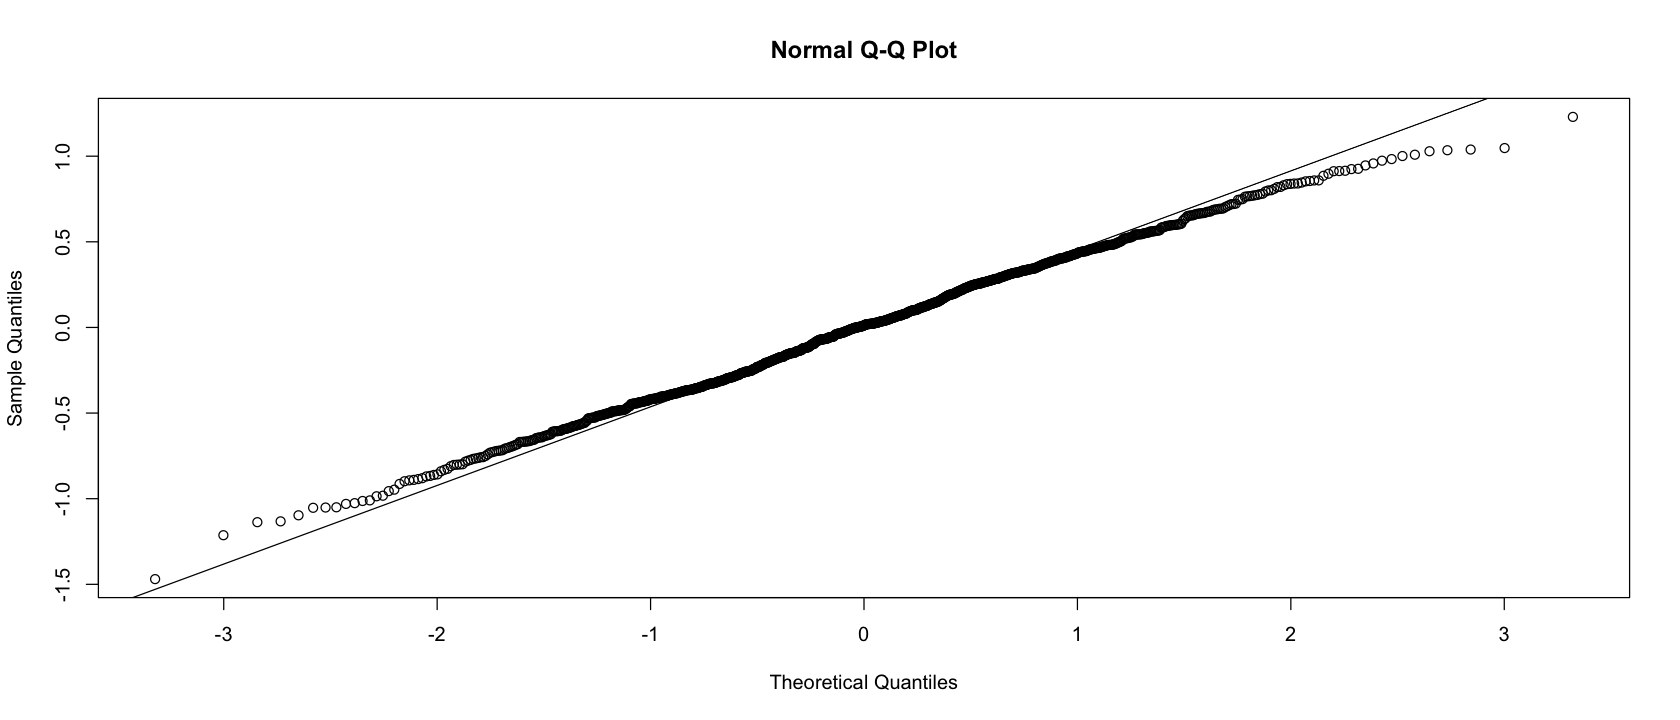

In [280]:
#diagnostics
leveneTest(log(mgN_shell_P2)~Phase_1_treat*Phase_2_treat, Shell_Nutrients) #FAILS LEVENE TEST
m1.e <- residuals(m1)
qqnorm(m1.e)
qqline(m1.e)

### 4.2 Mg Carbon Analysis

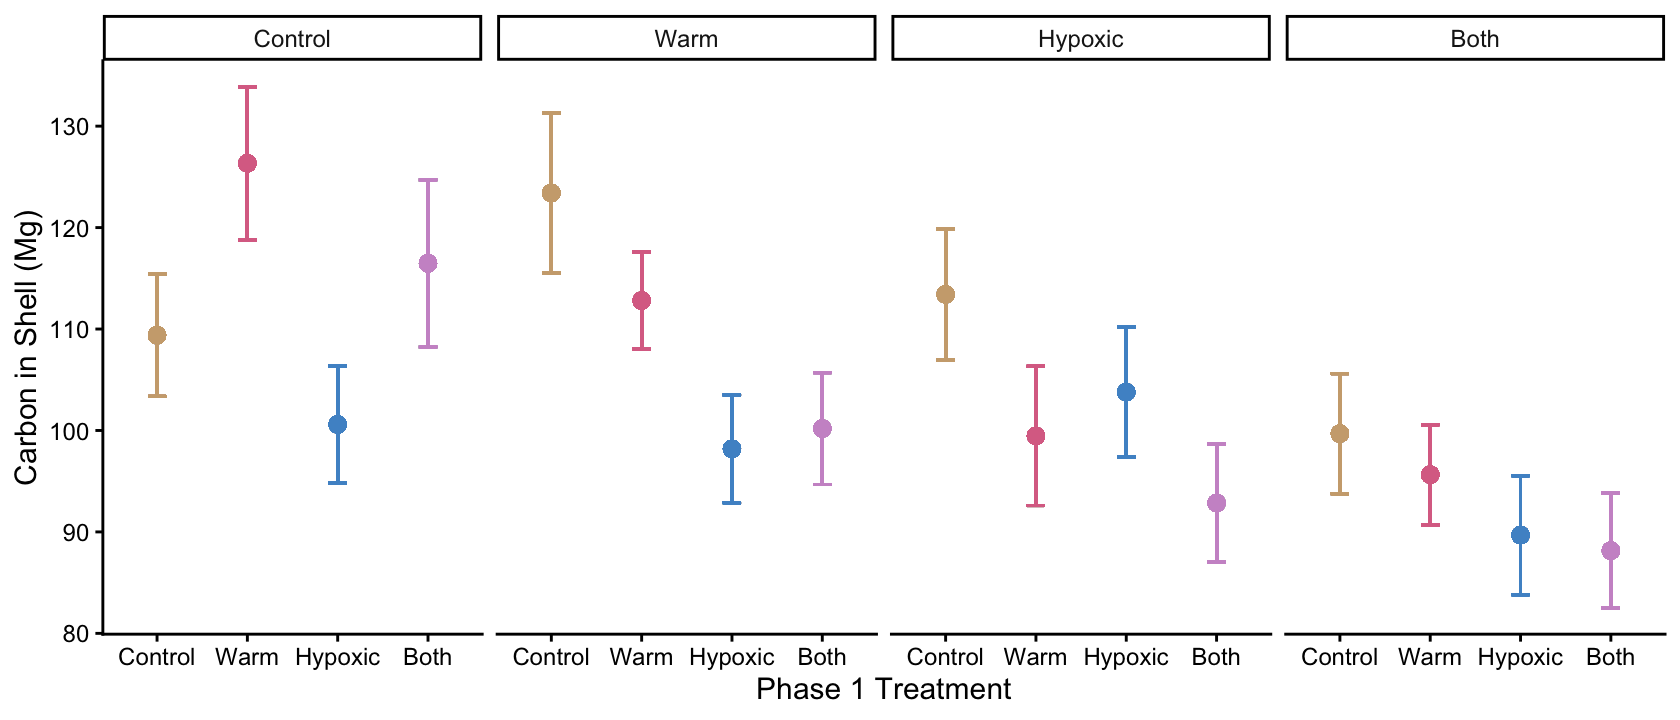

In [259]:
#format for jupyter
options(repr.plot.width = 14, repr.plot.height = 6)

#tissue nitrogen
summary_stats_t <- Shell_Nutrients %>%
  group_by(Phase_1_treat, Phase_2_treat) %>%
  mutate(
    mean_growth = mean(mgC_shell_P2, na.rm = TRUE),
    se_growth = std.error(mgC_shell_P2, na.rm = TRUE))

#reorder Phase_1_treat and Phase_2_treat
summary_stats_t$Phase_1_treat <- factor(summary_stats_t$Phase_1_treat, 
                                        levels = c("Cont", "Warm","Hyp", "Both"))
summary_stats_t$Phase_2_treat <- factor(summary_stats_t$Phase_2_treat, 
                                        levels = c("Cont", "Warm","Hyp", "Both"))

#plot with mean and SD, TISSUE
ggplot(summary_stats_t, aes(x = Phase_1_treat, y = mean_growth, color = Phase_1_treat)) +
  geom_point(size = 4, position = position_dodge(0.9)) + # Plot means as points
  geom_errorbar(aes(ymin = mean_growth - se_growth, ymax = mean_growth + se_growth), 
                width = 0.2, position = position_dodge(0.9)) + # Error bars for SD
  theme_classic(base_size = 18) +
  guides(color = "none") + # Remove legend for color
  facet_wrap(vars(Phase_2_treat), 
             labeller = as_labeller(c("Hyp" = "Hypoxic", "Cont" = "Control", "Warm" = "Warm", "Both" = "Both")), 
             scales = "fixed", nrow = 1) + # Facet by Phase_2_treat
  scale_color_manual(values = c("Hyp" = "steelblue3", "Warm" = "palevioletred", "Cont" = "burlywood3", "Both" = "plum3")) +
  labs(x = "Phase 1 Treatment", y = "Carbon in Shell (Mg)") +
  scale_x_discrete(labels = c("Hyp" = "Hypoxic", "Cont" = "Control", "Warm" = "Warm", "Both" = "Both")) +
  theme(legend.position = "none") # Remove legend

In [260]:
##Shell carbon
    #using tissue pre as a covariate
m1 <- lmer(mgC_shell_P2~ Phase_1_DO*Phase_1_temp*Phase_2.1_temp*Phase_2.1_DO+ Actual_tissue_pre_mg+
             (1|Phase_2_rep_R)+(1|Phase_1_rep_R)+
             (1|Phase_2_rep_R:Phase_1_DO)+(1|Phase_2_rep_R:Phase_1_temp)+(1|Phase_2_rep_R:Phase_1_DO:Phase_1_temp), data = Shell_Nutrients, REML=TRUE)
aov_tab<-Anova(m1, test="F", type="III")

#remove scientific notation
aov_tab %>%
  mutate(`Pr(>F)` = round(`Pr(>F)`, 4))

boundary (singular) fit: see help('isSingular')



,F,Df,Df.res,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),1.108161e+02,1,51.36879,0.0000
Phase_1_DO,5.144037e+00,1,13.20620,0.0407
Phase_1_temp,1.051415e-01,1,13.76883,0.7506
Phase_2.1_temp,1.805551e-01,1,19.93525,0.6754
Phase_2.1_DO,1.057583e+01,1,19.91232,0.0040
Actual_tissue_pre_mg,3.223048e+03,1,1039.24668,0.0000
Phase_1_DO:Phase_1_temp,1.593273e+00,1,13.04722,0.2290
Phase_1_DO:Phase_2.1_temp,2.129354e+00,1,19.95804,0.1601
Phase_1_temp:Phase_2.1_temp,1.044773e+00,1,19.97434,0.3189


In [261]:
##Shell carbon
    #using shell pre as a covariate
m1 <- lmer(mgC_shell_P2~ Phase_1_DO*Phase_1_temp*Phase_2.1_temp*Phase_2.1_DO+ Actual_shell_pre_mg+
             (1|Phase_2_rep_R)+(1|Phase_1_rep_R)+
             (1|Phase_2_rep_R:Phase_1_DO)+(1|Phase_2_rep_R:Phase_1_temp)+(1|Phase_2_rep_R:Phase_1_DO:Phase_1_temp), data = Shell_Nutrients, REML=TRUE)
aov_tab<-Anova(m1, test="F", type="III")

#remove scientific notation
aov_tab %>%
  mutate(`Pr(>F)` = round(`Pr(>F)`, 4))

boundary (singular) fit: see help('isSingular')



,F,Df,Df.res,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),5.253585e+01,1,33.33220,0.0000
Phase_1_DO,3.365075e-01,1,10.57533,0.5740
Phase_1_temp,6.458072e+00,1,11.91696,0.0260
Phase_2.1_temp,1.156283e-06,1,19.98958,0.9992
Phase_2.1_DO,8.011631e+00,1,19.97523,0.0103
Actual_shell_pre_mg,7.596008e+03,1,1074.17990,0.0000
Phase_1_DO:Phase_1_temp,9.515288e-01,1,10.30751,0.3517
Phase_1_DO:Phase_2.1_temp,1.210096e+00,1,19.95013,0.2844
Phase_1_temp:Phase_2.1_temp,1.649227e-01,1,19.98922,0.6890


,Df,F value,Pr(>F)
,<int>,<dbl>,<dbl>
group,15,1.675162,0.05006165
,1101,NA,NA


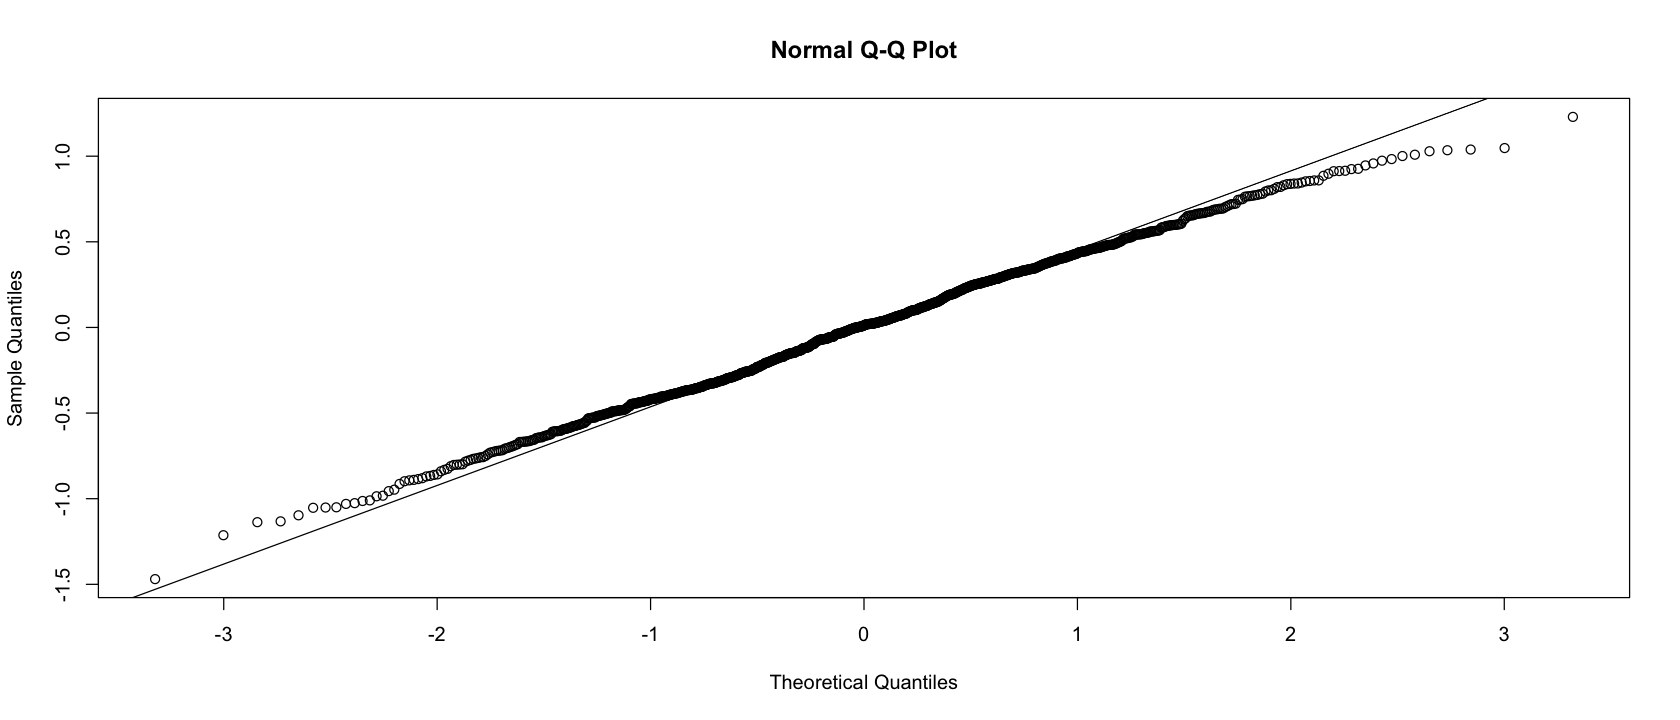

In [281]:
#diagnostics
leveneTest(mgC_shell_P2~Phase_1_treat*Phase_2_treat, Shell_Nutrients)
m1.e <- residuals(m1)
qqnorm(m1.e)
qqline(m1.e)